In [14]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [16]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

path = kagglehub.dataset_download("stefanoleone992/mutual-funds-and-etfs")
print("Path to dataset files:", path)
print("\nFiles:")
for f in sorted(os.listdir(path)):
    fsize = os.path.getsize(os.path.join(path, f)) / (1024**2)
    print(f"  {f}  ({fsize:.1f} MB)")

Path to dataset files: /Users/yogita/.cache/kagglehub/datasets/stefanoleone992/mutual-funds-and-etfs/versions/4

Files:
  ETF prices.csv  (192.0 MB)
  ETFs.csv  (3.6 MB)
  MutualFund prices - A-E.csv  (361.4 MB)
  MutualFund prices - F-K.csv  (455.7 MB)
  MutualFund prices - L-P.csv  (483.4 MB)
  MutualFund prices - Q-Z.csv  (408.6 MB)
  MutualFunds.csv  (73.0 MB)


In [18]:
# --- ETF data ---
etf_prices = pd.read_csv(os.path.join(path, "ETF prices.csv"))
etf_prices.columns = etf_prices.columns.str.strip()
etf_prices['price_date'] = pd.to_datetime(etf_prices['price_date'])
print(f"ETF Prices columns: {list(etf_prices.columns)}")

etf_info = pd.read_csv(os.path.join(path, "ETFs.csv"))
etf_info.columns = etf_info.columns.str.strip()

ETF Prices columns: ['fund_symbol', 'price_date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']


In [20]:
# --- Mutual Fund prices (4 split files) ---
mf_price_files = [
    "MutualFund prices - A-E.csv",
    "MutualFund prices - F-K.csv",
    "MutualFund prices - L-P.csv",
    "MutualFund prices - Q-Z.csv",
]
mf_parts = []
for f in mf_price_files:
    print(f"Loading {f}...")
    part = pd.read_csv(os.path.join(path, f))
    part.columns = part.columns.str.strip()
    mf_parts.append(part)
    print(f"  → {part.shape[0]:,} rows, columns: {list(part.columns)}")

mf_prices = pd.concat(mf_parts, ignore_index=True)
del mf_parts

print(f"\nMF Prices columns after merge: {list(mf_prices.columns)}")

Loading MutualFund prices - A-E.csv...
  → 16,016,010 rows, columns: ['fund_symbol', 'price_date', 'nav_per_share']
Loading MutualFund prices - F-K.csv...
  → 20,165,497 rows, columns: ['fund_symbol', 'price_date', 'nav_per_share']
Loading MutualFund prices - L-P.csv...
  → 21,426,733 rows, columns: ['fund_symbol', 'price_date', 'nav_per_share']
Loading MutualFund prices - Q-Z.csv...
  → 18,049,499 rows, columns: ['fund_symbol', 'price_date', 'nav_per_share']

MF Prices columns after merge: ['fund_symbol', 'price_date', 'nav_per_share']


In [22]:
# Standardize ticker column → 'ticker'
if 'ticker' not in mf_prices.columns:
    for candidate in ['fund_symbol', 'symbol', 'Symbol', 'Fund_Symbol']:
        if candidate in mf_prices.columns:
            mf_prices.rename(columns={candidate: 'ticker'}, inplace=True)
            print(f"Renamed '{candidate}' → 'ticker'")
            break

# Standardize date column → 'price_date'
if 'price_date' in mf_prices.columns:
    mf_prices['price_date'] = pd.to_datetime(mf_prices['price_date'])
else:
    for dcol in ['date', 'Date']:
        if dcol in mf_prices.columns:
            mf_prices[dcol] = pd.to_datetime(mf_prices[dcol])
            mf_prices.rename(columns={dcol: 'price_date'}, inplace=True)
            print(f"Renamed '{dcol}' → 'price_date'")
            break

# Standardize NAV column → 'nav_per_share'
if 'nav_per_share' not in mf_prices.columns:
    for candidate in ['close', 'Close', 'nav', 'NAV']:
        if candidate in mf_prices.columns:
            mf_prices.rename(columns={candidate: 'nav_per_share'}, inplace=True)
            print(f"Renamed '{candidate}' → 'nav_per_share'")
            break

print(f"Final MF Prices columns: {list(mf_prices.columns)}")

Renamed 'fund_symbol' → 'ticker'
Final MF Prices columns: ['ticker', 'price_date', 'nav_per_share']


In [24]:
# --- Mutual Fund info ---
mf_info = pd.read_csv(os.path.join(path, "MutualFunds.csv"))
mf_info.columns = mf_info.columns.str.strip()

print("\n" + "=" * 60)
print("LOADED DATASETS")
print("=" * 60)
print(f"ETF Prices:          {etf_prices.shape[0]:>12,} rows × {etf_prices.shape[1]} cols")
print(f"ETF Info:            {etf_info.shape[0]:>12,} rows × {etf_info.shape[1]} cols")
print(f"MF Prices (merged):  {mf_prices.shape[0]:>12,} rows × {mf_prices.shape[1]} cols")
print(f"MF Info:             {mf_info.shape[0]:>12,} rows × {mf_info.shape[1]} cols")


LOADED DATASETS
ETF Prices:             3,866,030 rows × 8 cols
ETF Info:                   2,310 rows × 142 cols
MF Prices (merged):    75,657,739 rows × 3 cols
MF Info:                   23,783 rows × 298 cols


In [26]:
# 2. Initial Inspection

print("ETF PRICES")
etf_prices.head()

print("MF PRICES")
mf_prices.head()

print(f"ETF INFO — {etf_info.shape[1]} columns")
print(list(etf_info.columns[:20]), "...")
etf_info.head(3)

print(f"MF INFO — {mf_info.shape[1]} columns")
print(list(mf_info.columns[:20]), "...")
mf_info.head(3)

ETF PRICES
MF PRICES
ETF INFO — 142 columns
['fund_symbol', 'quote_type', 'region', 'fund_short_name', 'fund_long_name', 'currency', 'fund_category', 'fund_family', 'exchange_code', 'exchange_name', 'exchange_timezone', 'avg_vol_3month', 'avg_vol_10day', 'total_net_assets', 'day50_moving_average', 'day200_moving_average', 'week52_high_low_change', 'week52_high_low_change_perc', 'week52_high', 'week52_high_change'] ...
MF INFO — 298 columns
['fund_symbol', 'quote_type', 'region', 'fund_short_name', 'fund_long_name', 'currency', 'initial_investment', 'subsequent_investment', 'fund_category', 'fund_family', 'exchange_code', 'exchange_name', 'exchange_timezone', 'management_name', 'management_bio', 'management_start_date', 'total_net_assets', 'year_to_date_return', 'day50_moving_average', 'day200_moving_average'] ...


,fund_symbol,quote_type,region,fund_short_name,fund_long_name,currency,initial_investment,subsequent_investment,fund_category,fund_family,...,peer_environment_avg,peer_environment_max,social_score,peer_social_min,peer_social_avg,peer_social_max,governance_score,peer_governance_min,peer_governance_avg,peer_governance_max
0,AAAAX,MutualFund,US,DWS RREEF Real Assets Fund - Cl,DWS RREEF Real Assets Fund - Class A,USD,1000.0,50.0,World Allocation,DWS,...,5.05,10.58,7.43,5.98,9.07,11.30,5.43,4.26,7.14,8.11
1,AAAEX,MutualFund,US,AllianzGI Health Sciences Fund,Virtus AllianzGI Health Sciences Fund Class P,USD,1000000.0,NaN,Health,Virtus,...,1.43,3.27,12.96,9.52,12.87,15.08,8.40,4.96,7.68,10.30
2,AAAFX,MutualFund,US,NaN,American Century One Choice Blend+ 2015 Portfo...,USD,2500.0,50.0,Target-Date 2015,American Century Investments,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


No missing values in ETF Prices!


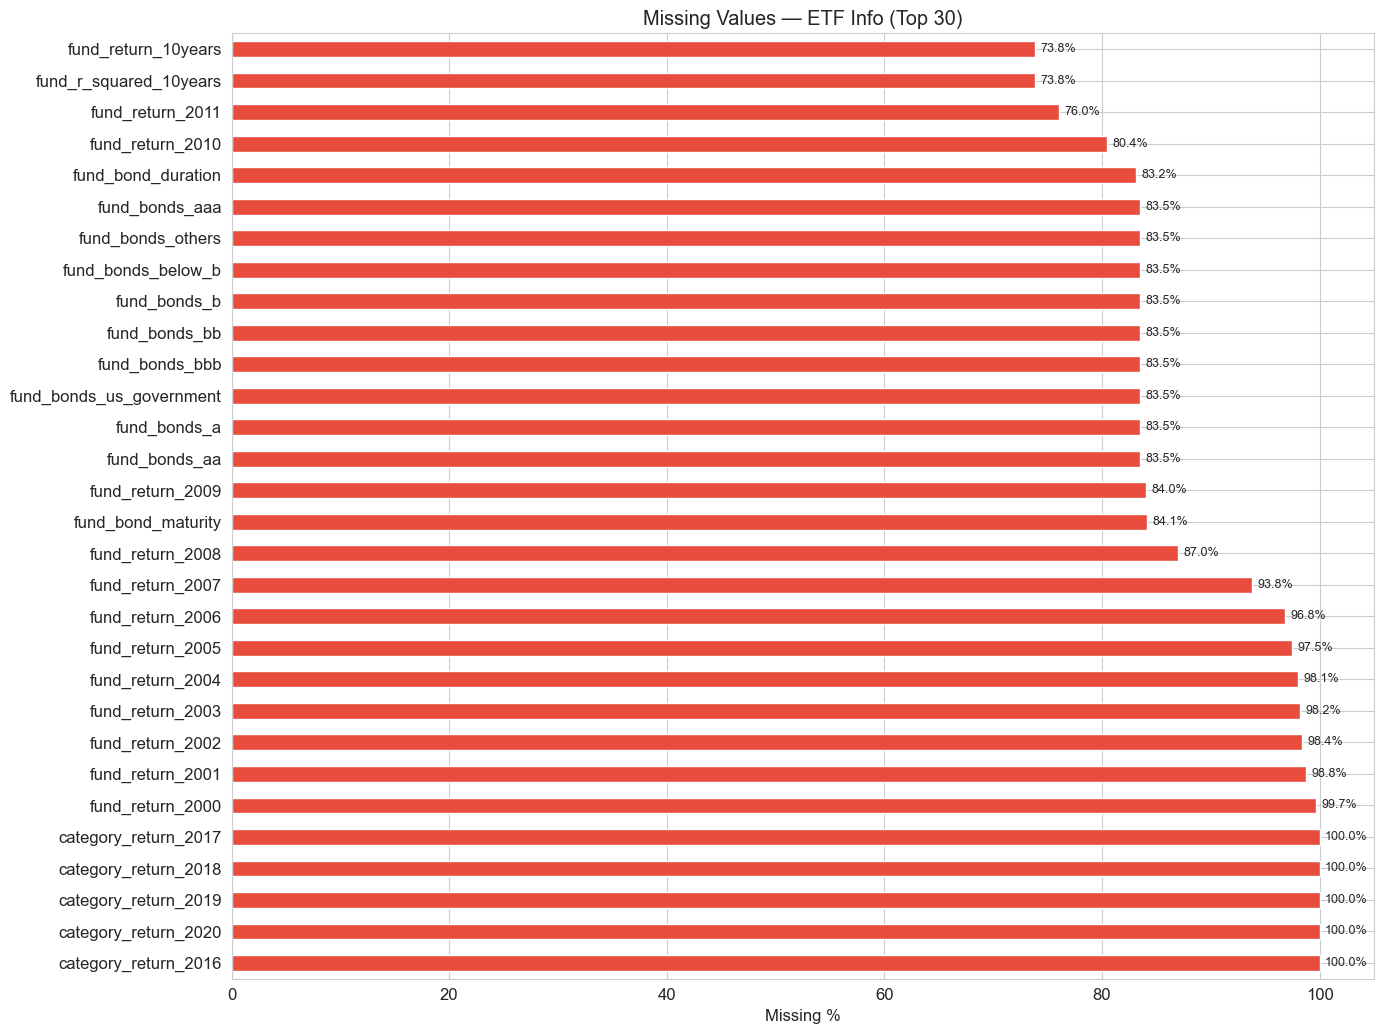

No missing values in Mutual Fund Prices!


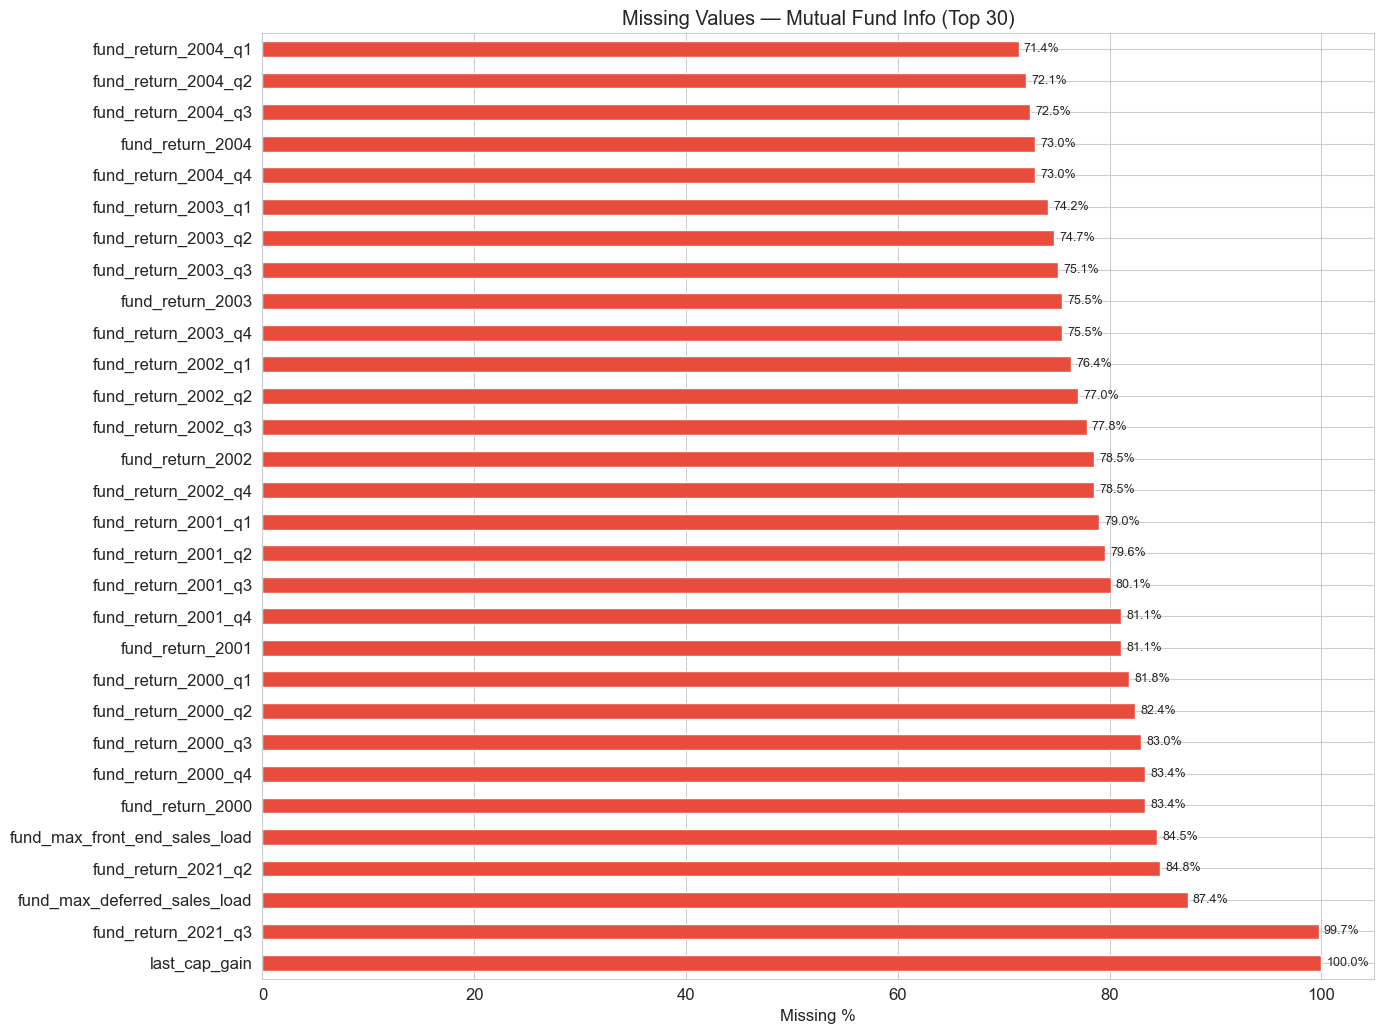

In [28]:
# 3. Missing Values Analysis

def plot_missing(df, title, top_n=30):
    missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing = missing[missing > 0].head(top_n)
    if len(missing) == 0:
        print(f"No missing values in {title}!")
        return
    fig, ax = plt.subplots(figsize=(14, max(4, len(missing) * 0.35)))
    colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#2ecc71' for v in missing.values]
    missing.plot(kind='barh', ax=ax, color=colors)
    ax.set_xlabel('Missing %')
    ax.set_title(f'Missing Values — {title}')
    for i, v in enumerate(missing.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_missing(etf_prices, "ETF Prices")
plot_missing(etf_info, "ETF Info (Top 30)")
plot_missing(mf_prices, "Mutual Fund Prices")
plot_missing(mf_info, "Mutual Fund Info (Top 30)")

Unique ETF symbols (prices):   2,310
Unique ETF symbols (info):     2,310
Unique MF tickers (prices):    23,783
Unique MF symbols (info):      23,783

ETF price date range:  1993-01-29 → 2021-11-30
MF price date range:   1973-05-03 → 2021-11-30


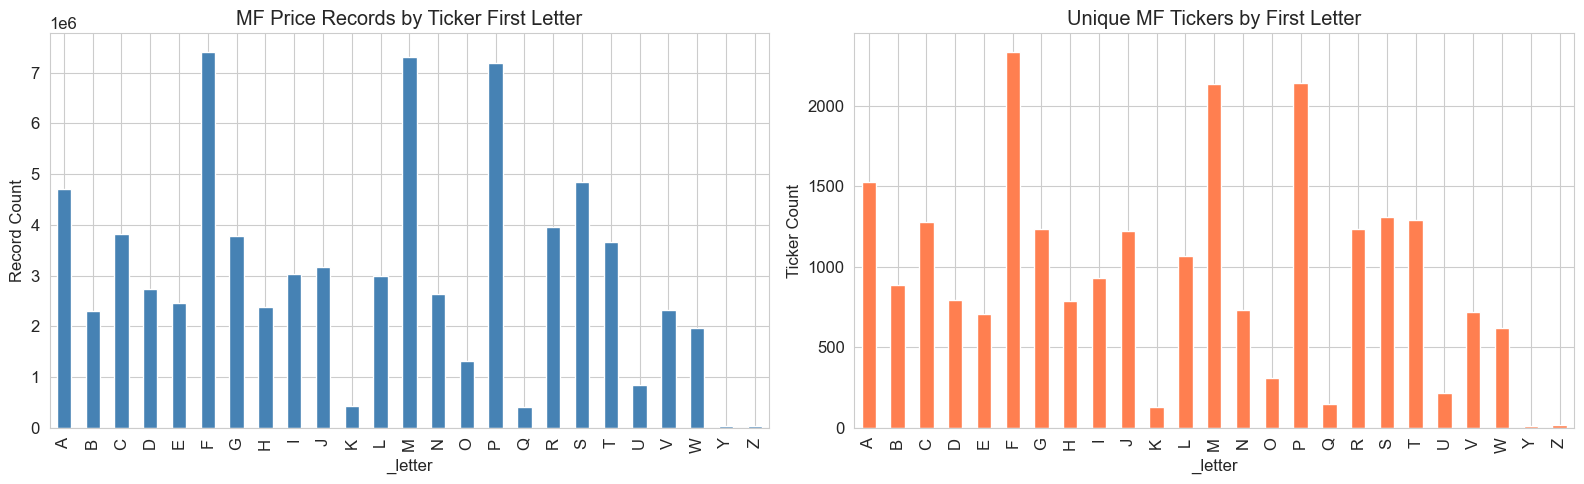

In [30]:
# 4. Summary Statistics

etf_prices.describe()
etf_info.describe()
mf_prices.describe()
mf_info.describe()

# 5. Data Coverage

print(f"Unique ETF symbols (prices):   {etf_prices['fund_symbol'].nunique():,}")
print(f"Unique ETF symbols (info):     {etf_info['fund_symbol'].nunique():,}")
print(f"Unique MF tickers (prices):    {mf_prices['ticker'].nunique():,}")
print(f"Unique MF symbols (info):      {mf_info['fund_symbol'].nunique():,}")

print(f"\nETF price date range:  {etf_prices['price_date'].min().date()} → {etf_prices['price_date'].max().date()}")
print(f"MF price date range:   {mf_prices['price_date'].min().date()} → {mf_prices['price_date'].max().date()}")


# Records per first letter (verify MF split file coverage)
mf_prices['_letter'] = mf_prices['ticker'].str[0].str.upper()
letter_dist = mf_prices.groupby('_letter').agg(
    records=('ticker', 'count'),
    unique_tickers=('ticker', 'nunique')
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
letter_dist['records'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MF Price Records by Ticker First Letter')
axes[0].set_ylabel('Record Count')
letter_dist['unique_tickers'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Unique MF Tickers by First Letter')
axes[1].set_ylabel('Ticker Count')
plt.tight_layout()
plt.show()
mf_prices.drop(columns='_letter', inplace=True)

Top 10 ETFs by record count: ['SPY', 'EWC', 'EWA', 'EWD', 'DIA', 'QQQ', 'IVV', 'IWB', 'IWF', 'IVE']


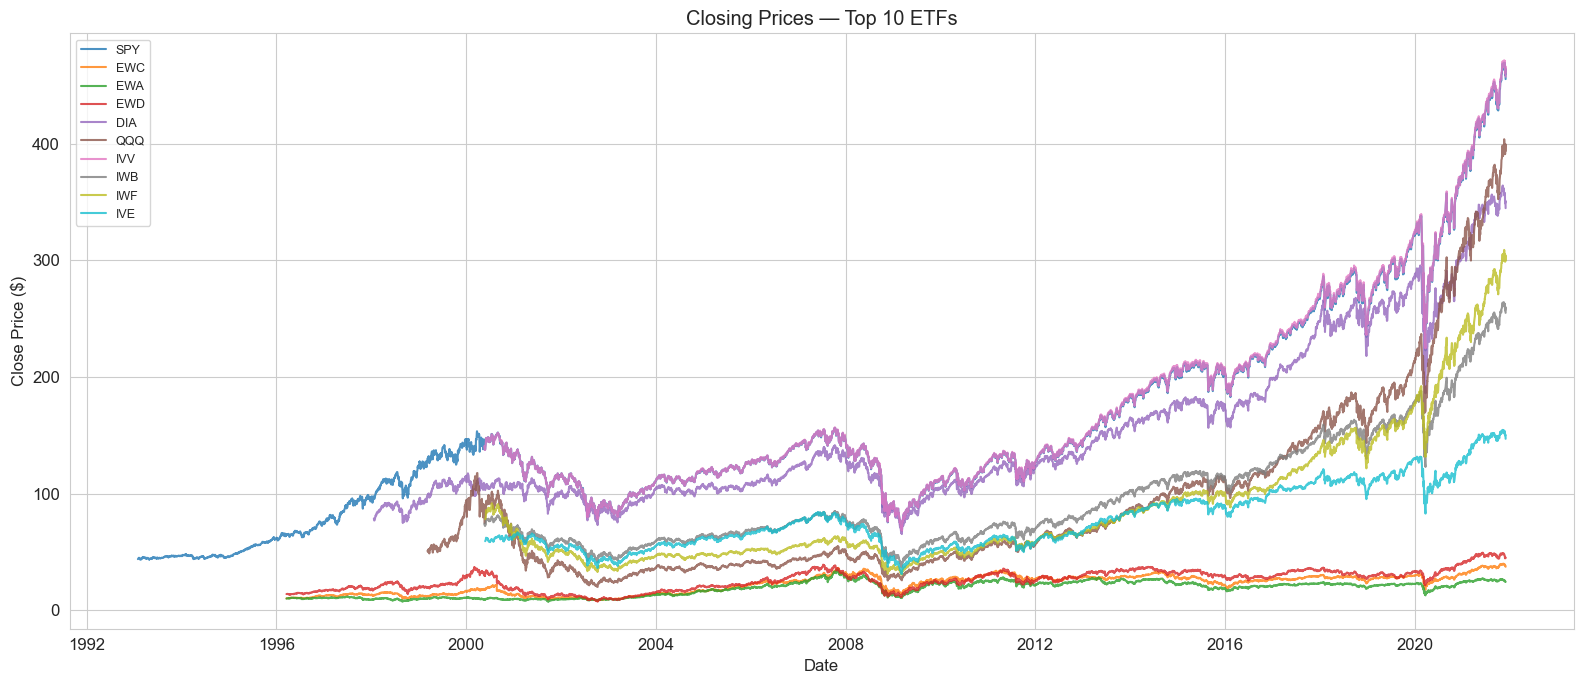

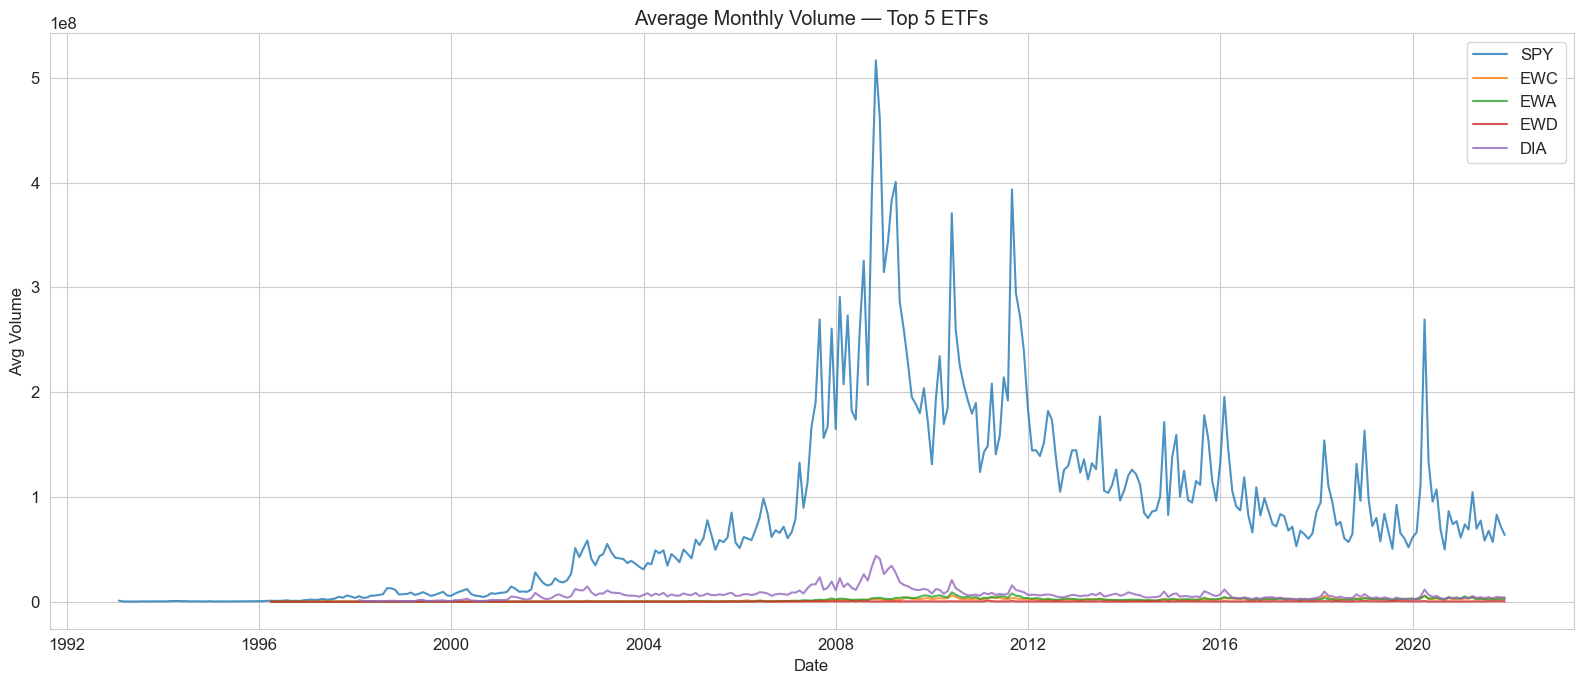

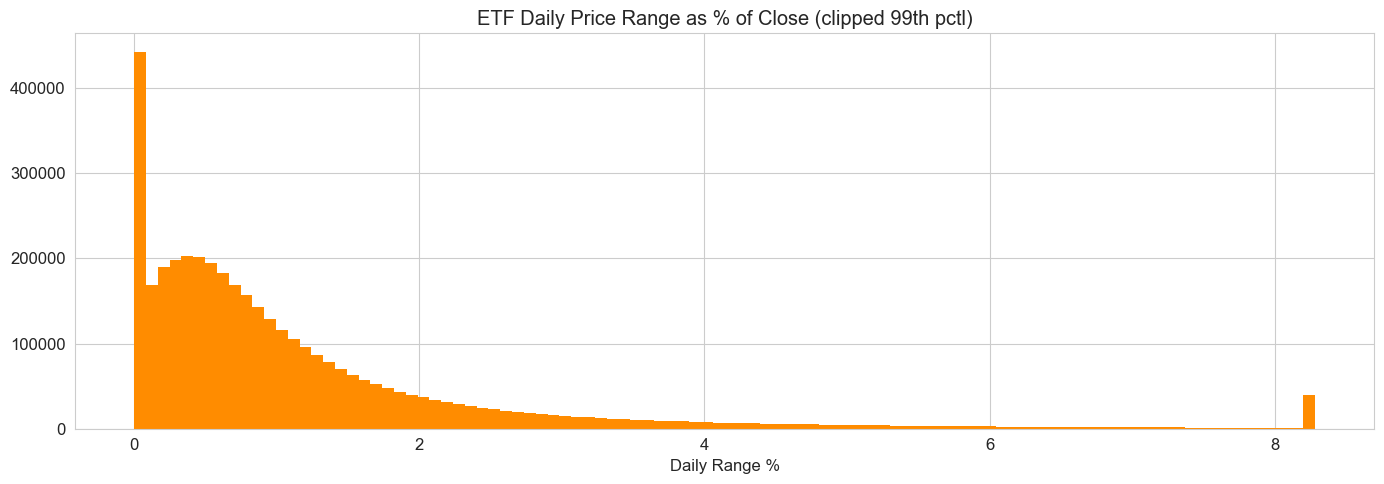

In [32]:
# 6. ETF Prices — Time Series Analysis

top_etfs = etf_prices['fund_symbol'].value_counts().head(10).index.tolist()
print("Top 10 ETFs by record count:", top_etfs)

fig, ax = plt.subplots(figsize=(16, 7))
for sym in top_etfs:
    sub = etf_prices[etf_prices['fund_symbol'] == sym].sort_values('price_date')
    ax.plot(sub['price_date'], sub['close'], label=sym, alpha=0.8)
ax.set_title('Closing Prices — Top 10 ETFs')
ax.set_xlabel('Date'); ax.set_ylabel('Close Price ($)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 7))
for sym in top_etfs[:5]:
    sub = etf_prices[etf_prices['fund_symbol'] == sym].sort_values('price_date')
    monthly = sub.set_index('price_date')['volume'].resample('M').mean()
    ax.plot(monthly.index, monthly.values, label=sym, alpha=0.8)
ax.set_title('Average Monthly Volume — Top 5 ETFs')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Volume')
ax.legend()
plt.tight_layout(); plt.show()

# Daily price range (high - low) as % of close
etf_prices['daily_range_pct'] = (etf_prices['high'] - etf_prices['low']) / etf_prices['close'] * 100
fig, ax = plt.subplots(figsize=(14, 5))
etf_prices['daily_range_pct'].clip(upper=etf_prices['daily_range_pct'].quantile(0.99)).hist(
    bins=100, ax=ax, color='darkorange', edgecolor='none')
ax.set_title('ETF Daily Price Range as % of Close (clipped 99th pctl)')
ax.set_xlabel('Daily Range %')
plt.tight_layout(); plt.show()

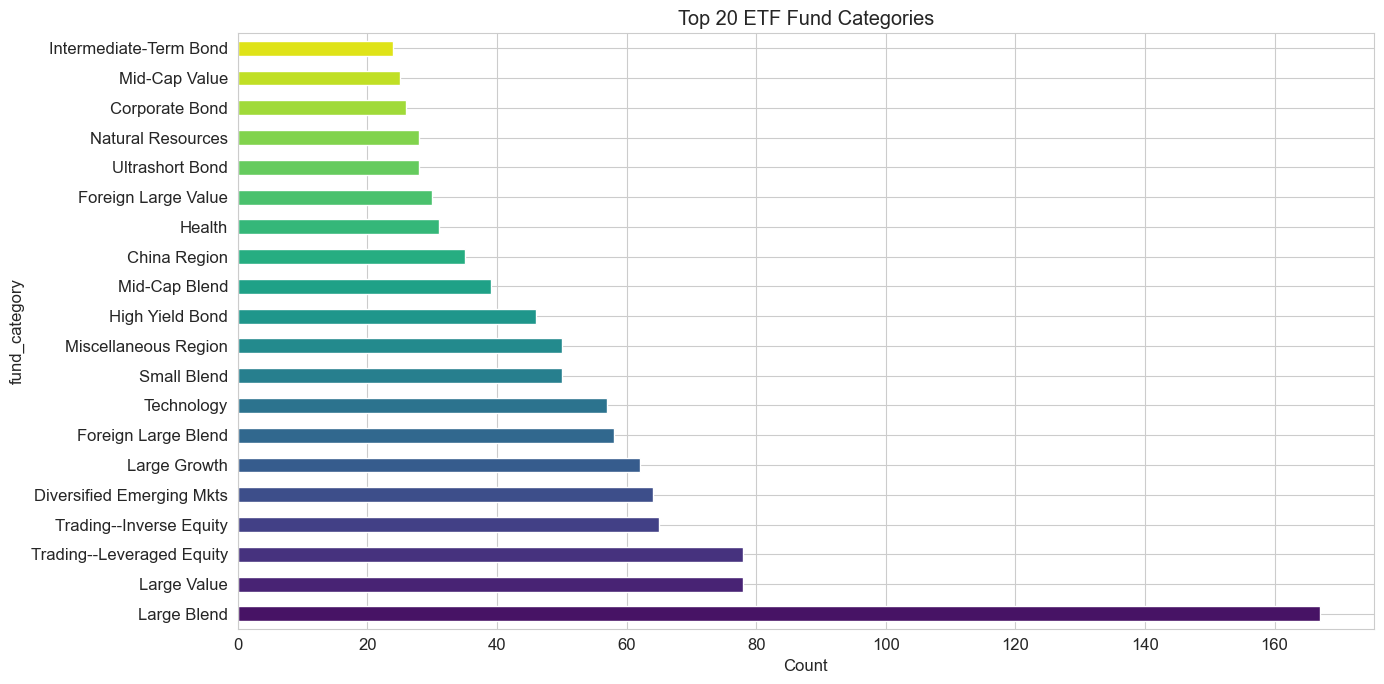

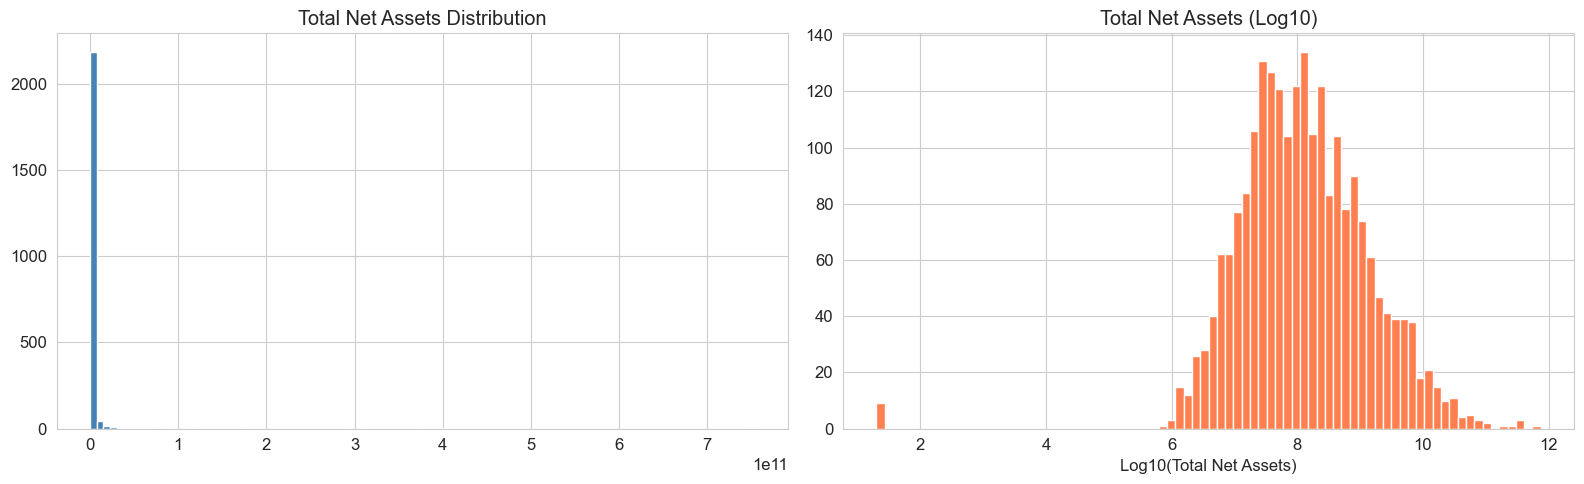

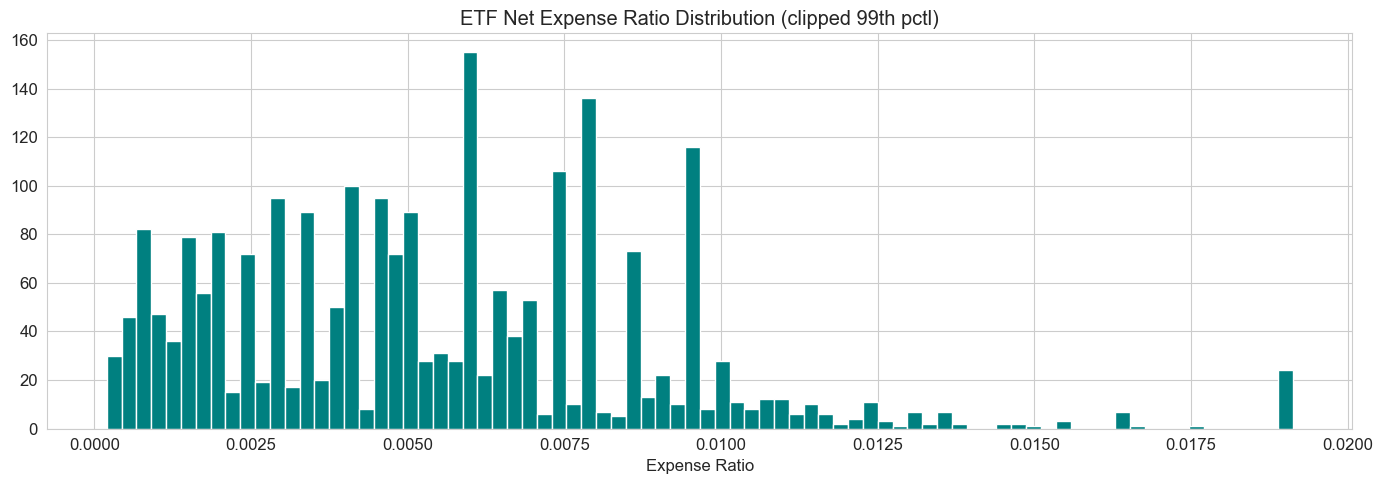

count    2295.000000
mean        0.005553
std         0.004413
min         0.000200
25%         0.002900
50%         0.005000
75%         0.007500
max         0.102300
Name: fund_annual_report_net_expense_ratio, dtype: float64


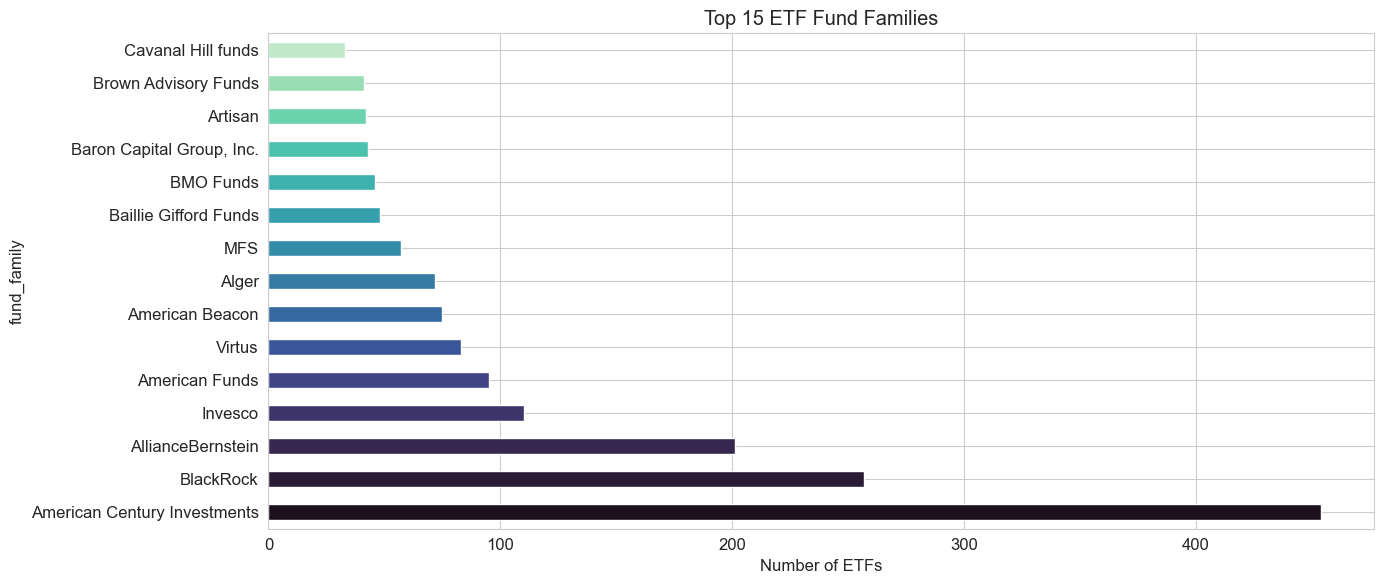

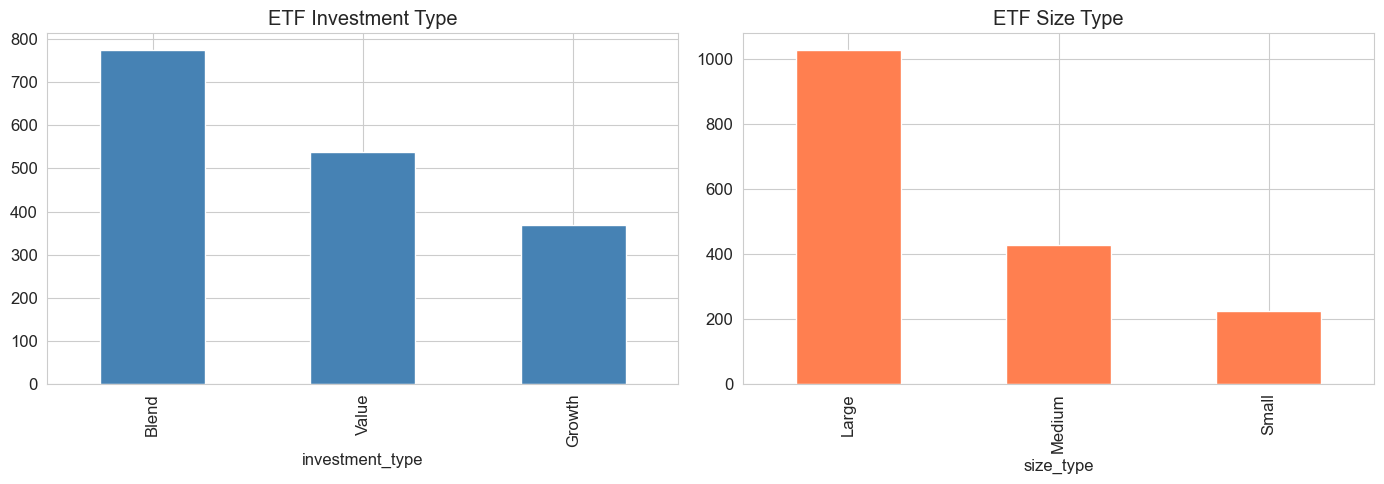

In [34]:
# 7. ETF Info — Fund Characteristics

top_cats = etf_info['fund_category'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(14, 7))
top_cats.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(top_cats)))
ax.set_title('Top 20 ETF Fund Categories')
ax.set_xlabel('Count')
plt.tight_layout(); plt.show()

# Total Net Assets
tna = etf_info['total_net_assets'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(tna, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Total Net Assets Distribution')
tna_log = np.log10(tna[tna > 0])
axes[1].hist(tna_log, bins=80, color='coral', edgecolor='white')
axes[1].set_title('Total Net Assets (Log10)')
axes[1].set_xlabel('Log10(Total Net Assets)')
plt.tight_layout(); plt.show()

# Expense Ratio
exp = etf_info['fund_annual_report_net_expense_ratio'].dropna()
fig, ax = plt.subplots(figsize=(14, 5))
exp.clip(upper=exp.quantile(0.99)).hist(bins=80, ax=ax, color='teal', edgecolor='white')
ax.set_title('ETF Net Expense Ratio Distribution (clipped 99th pctl)')
ax.set_xlabel('Expense Ratio')
plt.tight_layout(); plt.show()
print(exp.describe())

# Fund Families (top 15)
top_fam = etf_info['fund_family'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(14, 6))
top_fam.plot(kind='barh', ax=ax, color=sns.color_palette('mako', len(top_fam)))
ax.set_title('Top 15 ETF Fund Families')
ax.set_xlabel('Number of ETFs')
plt.tight_layout(); plt.show()

# Investment Type & Size Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
etf_info['investment_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('ETF Investment Type')
etf_info['size_type'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('ETF Size Type')
plt.tight_layout(); plt.show()

Unique Mutual Funds: 23,783
Total records: 75,657,739
Date range: 1973-05-03 → 2021-11-30


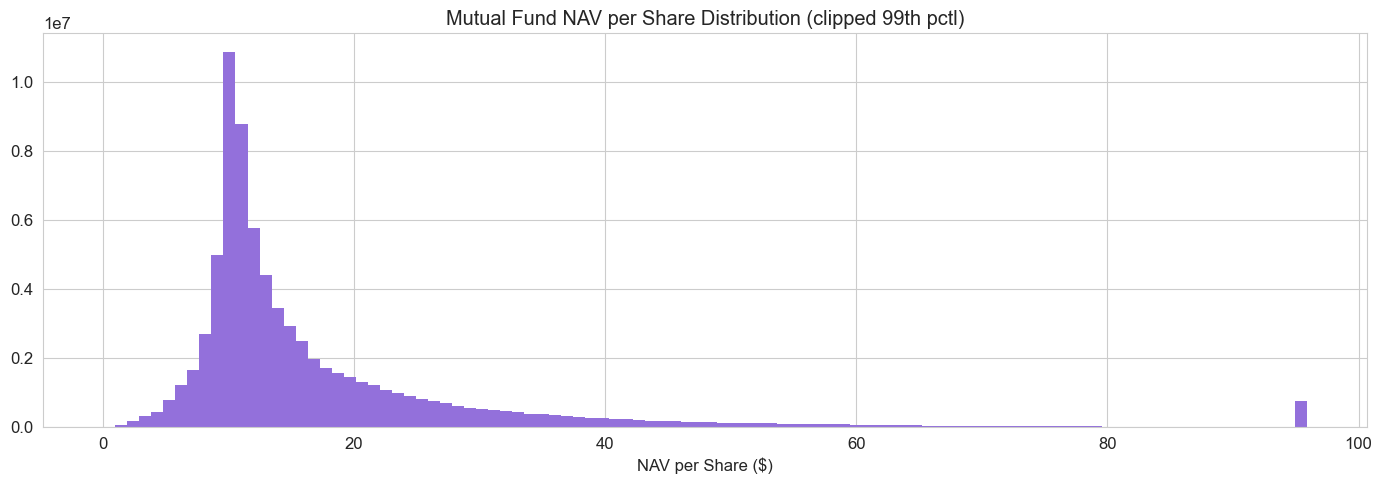

count    7.565774e+07
mean     2.914629e+01
std      1.230306e+03
min      0.000000e+00
25%      1.018000e+01
50%      1.248000e+01
75%      1.943000e+01
max      7.552500e+05
Name: nav_per_share, dtype: float64
Top 10 MFs by record count: ['MITTX', 'MFRFX', 'ACGIX', 'ACSTX', 'MIGFX', 'SHAPX', 'PGEOX', 'MAPOX', 'SENCX', 'PIODX']


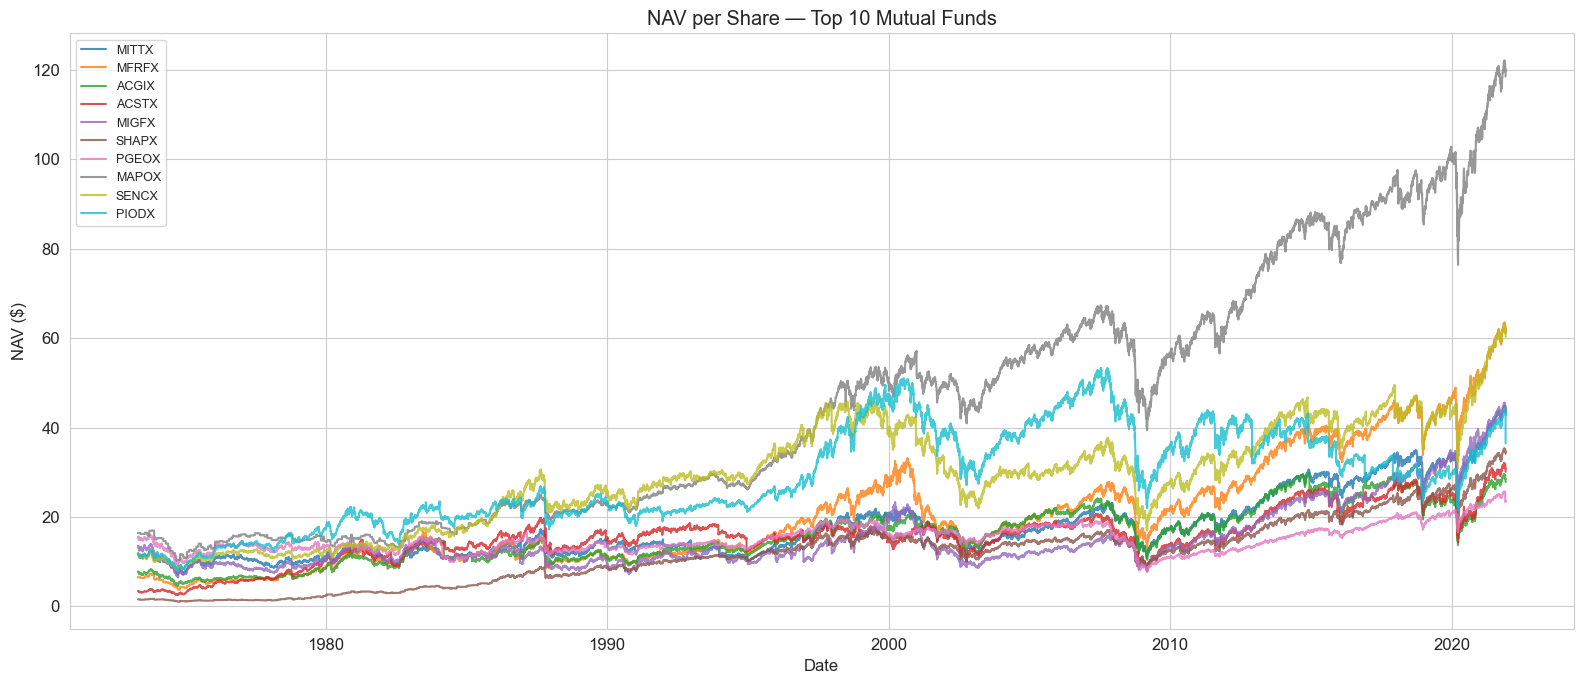

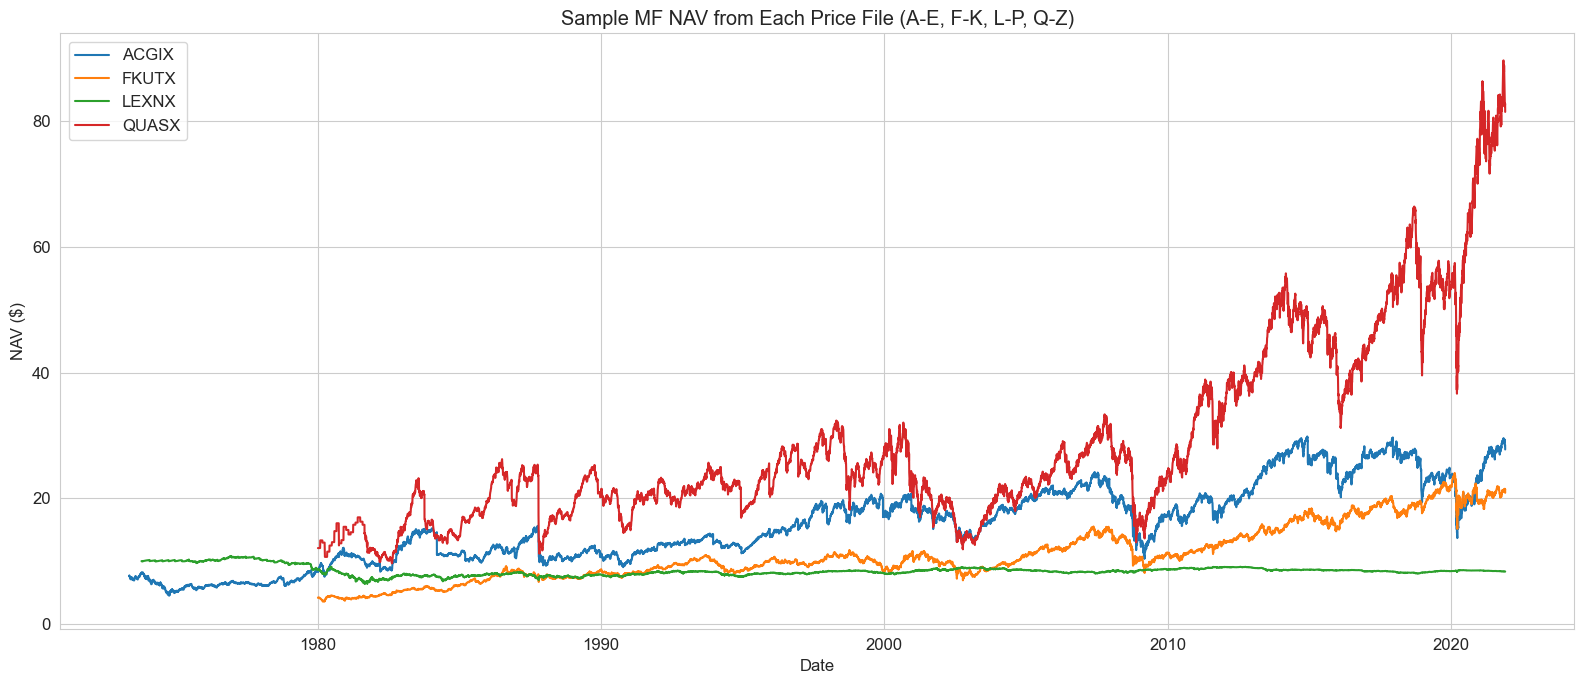

In [36]:
# 8. Mutual Fund Prices — Time Series (NAV)

n_mf = mf_prices['ticker'].nunique()
print(f"Unique Mutual Funds: {n_mf:,}")
print(f"Total records: {mf_prices.shape[0]:,}")
print(f"Date range: {mf_prices['price_date'].min().date()} → {mf_prices['price_date'].max().date()}")

# NAV distribution
nav = mf_prices['nav_per_share'].dropna()
fig, ax = plt.subplots(figsize=(14, 5))
nav.clip(upper=nav.quantile(0.99)).hist(bins=100, ax=ax, color='mediumpurple', edgecolor='none')
ax.set_title('Mutual Fund NAV per Share Distribution (clipped 99th pctl)')
ax.set_xlabel('NAV per Share ($)')
plt.tight_layout(); plt.show()
print(nav.describe())

# Top 10 MFs by record count — NAV over time
top_mfs = mf_prices['ticker'].value_counts().head(10).index.tolist()
print("Top 10 MFs by record count:", top_mfs)

fig, ax = plt.subplots(figsize=(16, 7))
for t in top_mfs:
    sub = mf_prices[mf_prices['ticker'] == t].sort_values('price_date')
    ax.plot(sub['price_date'], sub['nav_per_share'], label=t, alpha=0.8)
ax.set_title('NAV per Share — Top 10 Mutual Funds')
ax.set_xlabel('Date'); ax.set_ylabel('NAV ($)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

# Sample one MF from each split file range
sample_tickers = []
for letter in ['A', 'F', 'L', 'Q']:
    candidates = mf_prices[mf_prices['ticker'].str.startswith(letter)]['ticker'].value_counts()
    if len(candidates) > 0:
        sample_tickers.append(candidates.index[0])

fig, ax = plt.subplots(figsize=(16, 7))
for t in sample_tickers:
    sub = mf_prices[mf_prices['ticker'] == t].sort_values('price_date')
    ax.plot(sub['price_date'], sub['nav_per_share'], label=t, linewidth=1.5)
ax.set_title('Sample MF NAV from Each Price File (A-E, F-K, L-P, Q-Z)')
ax.set_xlabel('Date'); ax.set_ylabel('NAV ($)')
ax.legend()
plt.tight_layout(); plt.show()

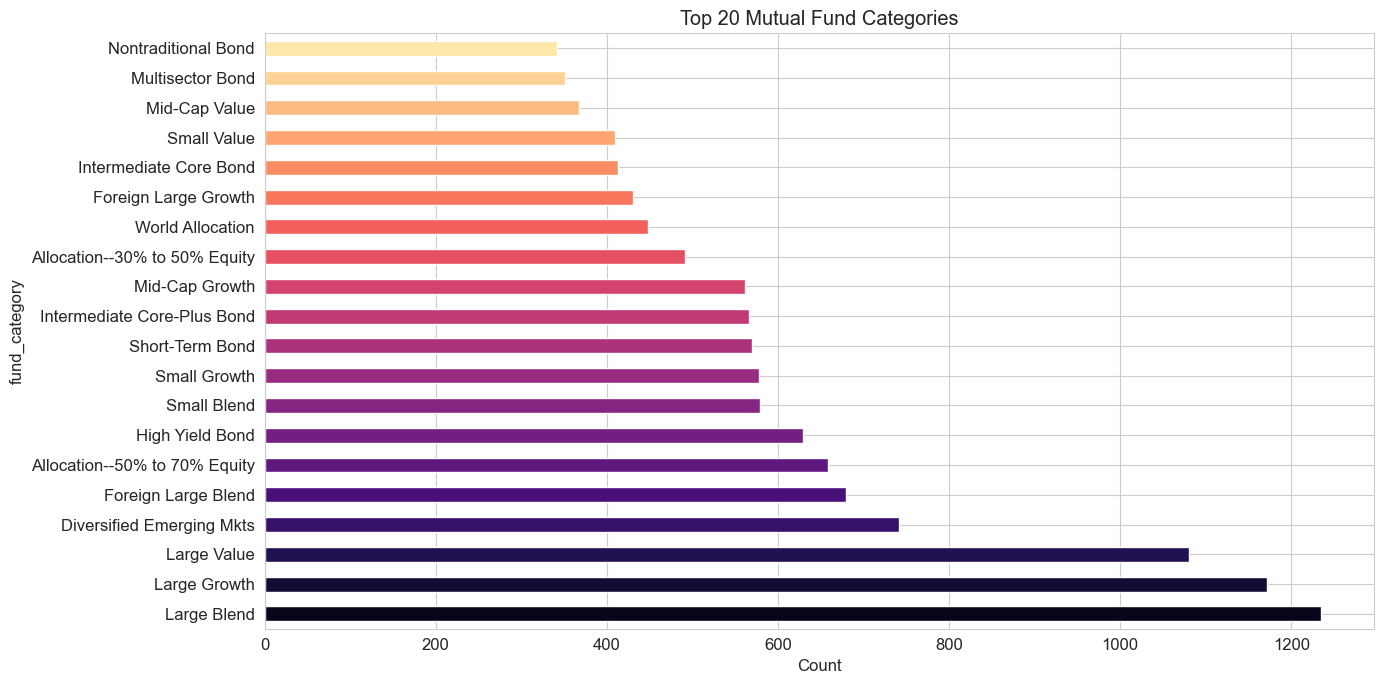

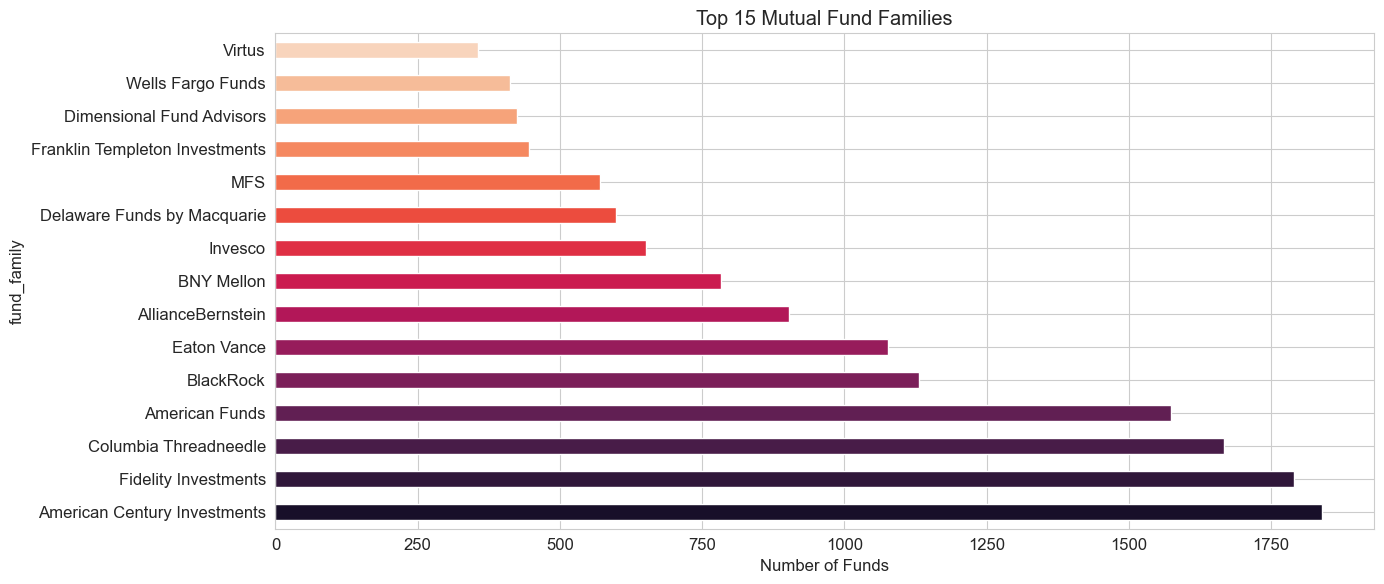

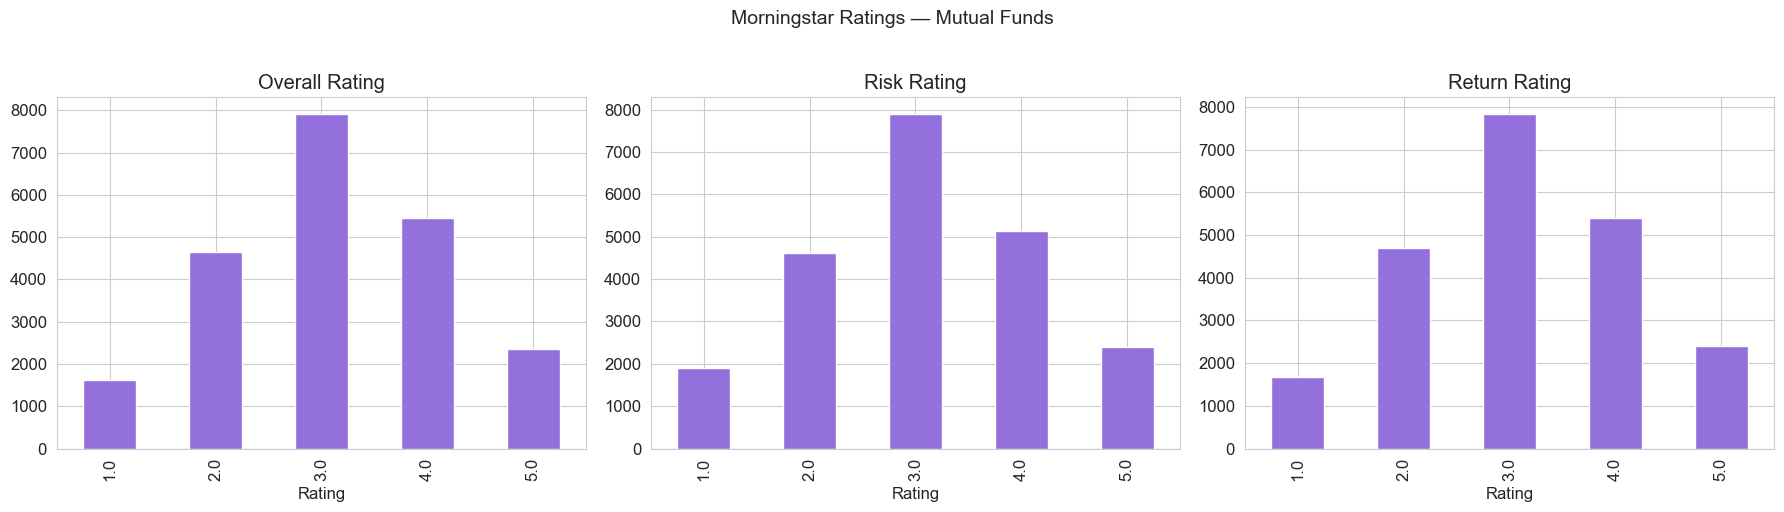

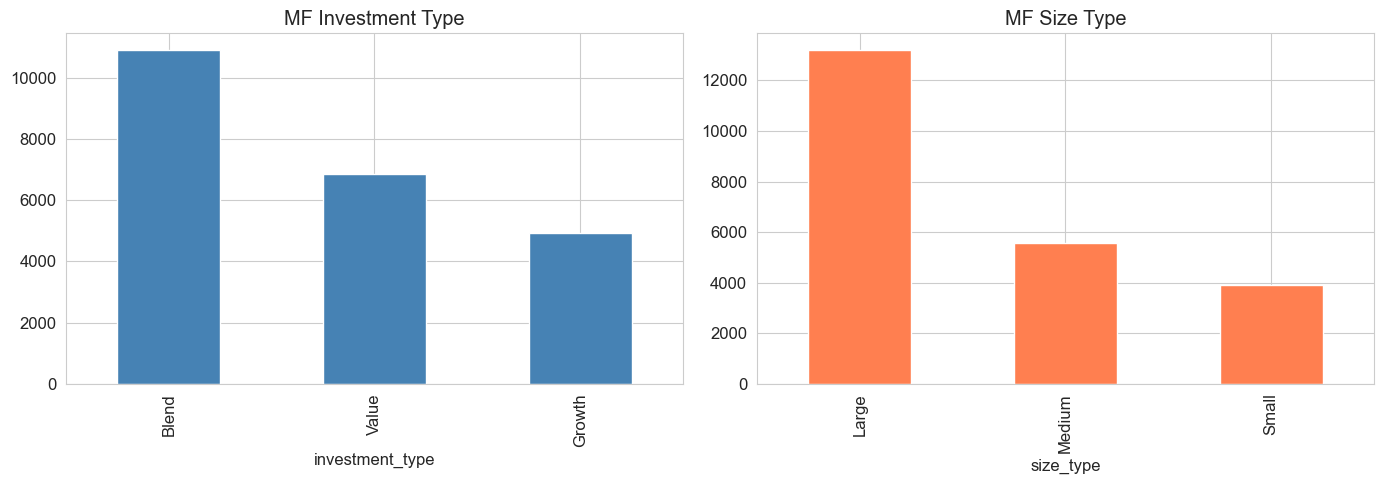

Funds with ESG data: 15,407 / 23,783


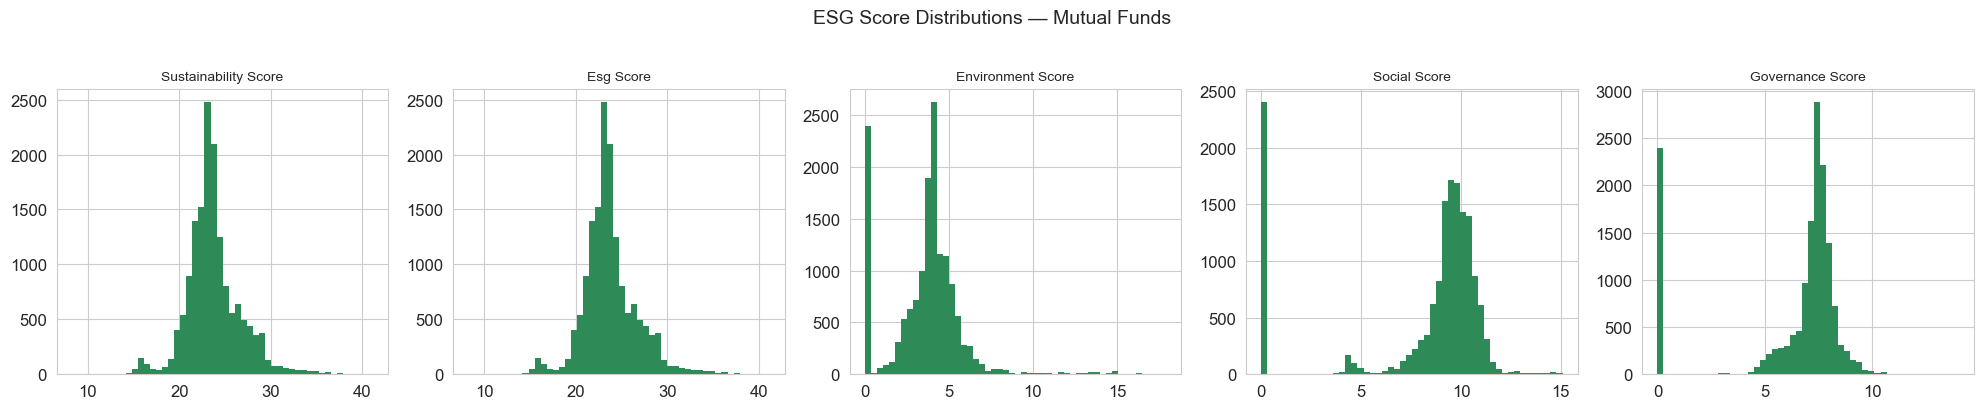

In [37]:
# 9. Mutual Fund Info — Characteristics

top_mf_cats = mf_info['fund_category'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(14, 7))
top_mf_cats.plot(kind='barh', ax=ax, color=sns.color_palette('magma', len(top_mf_cats)))
ax.set_title('Top 20 Mutual Fund Categories')
ax.set_xlabel('Count')
plt.tight_layout(); plt.show()

top_mf_fam = mf_info['fund_family'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(14, 6))
top_mf_fam.plot(kind='barh', ax=ax, color=sns.color_palette('rocket', len(top_mf_fam)))
ax.set_title('Top 15 Mutual Fund Families')
ax.set_xlabel('Number of Funds')
plt.tight_layout(); plt.show()

# Morningstar Ratings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['morningstar_overall_rating', 'morningstar_risk_rating', 'morningstar_return_rating']):
    mf_info[col].dropna().value_counts().sort_index().plot(kind='bar', ax=axes[i], color='mediumpurple')
    axes[i].set_title(col.replace('morningstar_', '').replace('_', ' ').title())
    axes[i].set_xlabel('Rating')
plt.suptitle('Morningstar Ratings — Mutual Funds', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


# Investment type & size type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mf_info['investment_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MF Investment Type')
mf_info['size_type'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('MF Size Type')
plt.tight_layout(); plt.show()

# ESG Scores (unique to MF info)
esg_cols = ['sustainability_score', 'esg_score', 'environment_score', 'social_score', 'governance_score']
esg_avail = [c for c in esg_cols if c in mf_info.columns]
if esg_avail:
    esg_data = mf_info[esg_avail].dropna(how='all')
    print(f"Funds with ESG data: {len(esg_data):,} / {len(mf_info):,}")
    fig, axes = plt.subplots(1, len(esg_avail), figsize=(4 * len(esg_avail), 4))
    if len(esg_avail) == 1:
        axes = [axes]
    for i, col in enumerate(esg_avail):
        mf_info[col].dropna().hist(bins=50, ax=axes[i], color='seagreen', edgecolor='none')
        axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    plt.suptitle('ESG Score Distributions — Mutual Funds', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

Available columns (17/17): ['total_net_assets', 'fund_yield', 'fund_annual_report_net_expense_ratio', 'annual_holdings_turnover', 'asset_stocks', 'asset_bonds', 'fund_price_book_ratio', 'fund_price_earning_ratio', 'fund_return_ytd', 'fund_return_1year', 'fund_return_3years', 'fund_return_5years', 'fund_sharpe_ratio_3years', 'fund_beta_3years', 'fund_stdev_3years', 'fund_alpha_3years', 'fund_treynor_ratio_3years']

Non-null counts:
total_net_assets                        2280
fund_yield                              1595
fund_annual_report_net_expense_ratio    2295
annual_holdings_turnover                1360
asset_stocks                            1274
asset_bonds                             1274
fund_price_book_ratio                   1597
fund_price_earning_ratio                1496
fund_return_ytd                         2109
fund_return_1year                       1917
fund_return_3years                      1501
fund_return_5years                      1138
fund_sharpe_ratio_3years 

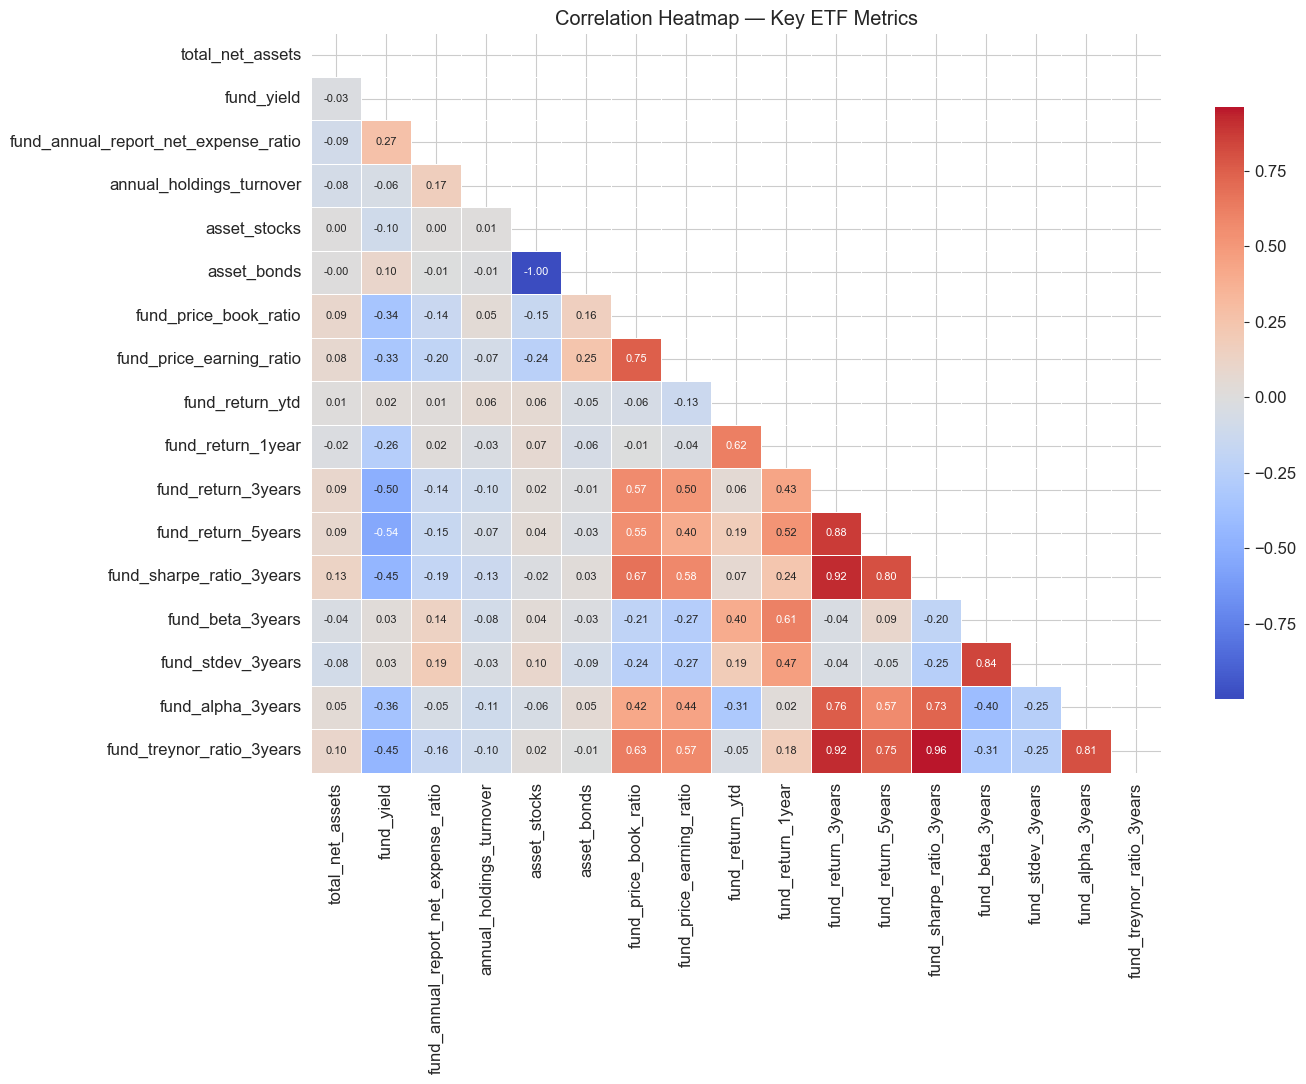

TOP 10 POSITIVE CORRELATIONS:
fund_price_book_ratio     fund_price_earning_ratio     0.751696
fund_return_5years        fund_treynor_ratio_3years    0.753238
fund_return_3years        fund_alpha_3years            0.761810
fund_return_5years        fund_sharpe_ratio_3years     0.802363
fund_alpha_3years         fund_treynor_ratio_3years    0.807131
fund_beta_3years          fund_stdev_3years            0.839338
fund_return_3years        fund_return_5years           0.876570
                          fund_treynor_ratio_3years    0.917800
                          fund_sharpe_ratio_3years     0.919550
fund_sharpe_ratio_3years  fund_treynor_ratio_3years    0.961075

TOP 10 NEGATIVE CORRELATIONS:
asset_stocks      asset_bonds                 -0.998624
fund_yield        fund_return_5years          -0.541214
                  fund_return_3years          -0.503589
                  fund_sharpe_ratio_3years    -0.453732
                  fund_treynor_ratio_3years   -0.449433
fund_beta_3years  f

In [60]:
# 10. Correlation Analysis

etf_key_cols = [
    'total_net_assets', 'fund_yield', 'fund_annual_report_net_expense_ratio',
    'annual_holdings_turnover', 'asset_stocks', 'asset_bonds',
    'fund_price_book_ratio', 'fund_price_earning_ratio',
    'fund_return_ytd', 'fund_return_1year', 'fund_return_3years', 'fund_return_5years',
    'fund_sharpe_ratio_3years', 'fund_beta_3years', 'fund_stdev_3years',
    'fund_alpha_3years', 'fund_treynor_ratio_3years'
]
etf_key_avail = [c for c in etf_key_cols if c in etf_info.columns]
print(f"Available columns ({len(etf_key_avail)}/{len(etf_key_cols)}): {etf_key_avail}")

# Keep only columns that have enough non-null values
etf_key = etf_info[etf_key_avail]
non_null_counts = etf_key.notnull().sum()
print(f"\nNon-null counts:\n{non_null_counts.to_string()}")
good_cols = non_null_counts[non_null_counts >= 50].index.tolist()
etf_key = etf_key[good_cols].dropna()
print(f"\nUsing {len(good_cols)} columns, {len(etf_key)} rows after dropna")

if len(good_cols) >= 2 and len(etf_key) >= 10:
    corr = etf_key.corr()
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
    ax.set_title('Correlation Heatmap — Key ETF Metrics')
    plt.tight_layout(); plt.show()

    # Top correlations
    upper = corr.where(~np.triu(np.ones_like(corr, dtype=bool)))
    pairs = upper.unstack().dropna().sort_values()
    pairs = pairs[pairs.abs() < 1.0]
    print("TOP 10 POSITIVE CORRELATIONS:")
    print(pairs.tail(10).to_string())
    print("\nTOP 10 NEGATIVE CORRELATIONS:")
    print(pairs.head(10).to_string())
else:
    print("Not enough data for correlation heatmap.")
    print(f"  Columns with ≥50 non-null: {len(good_cols)}, Rows after dropna: {len(etf_key)}")

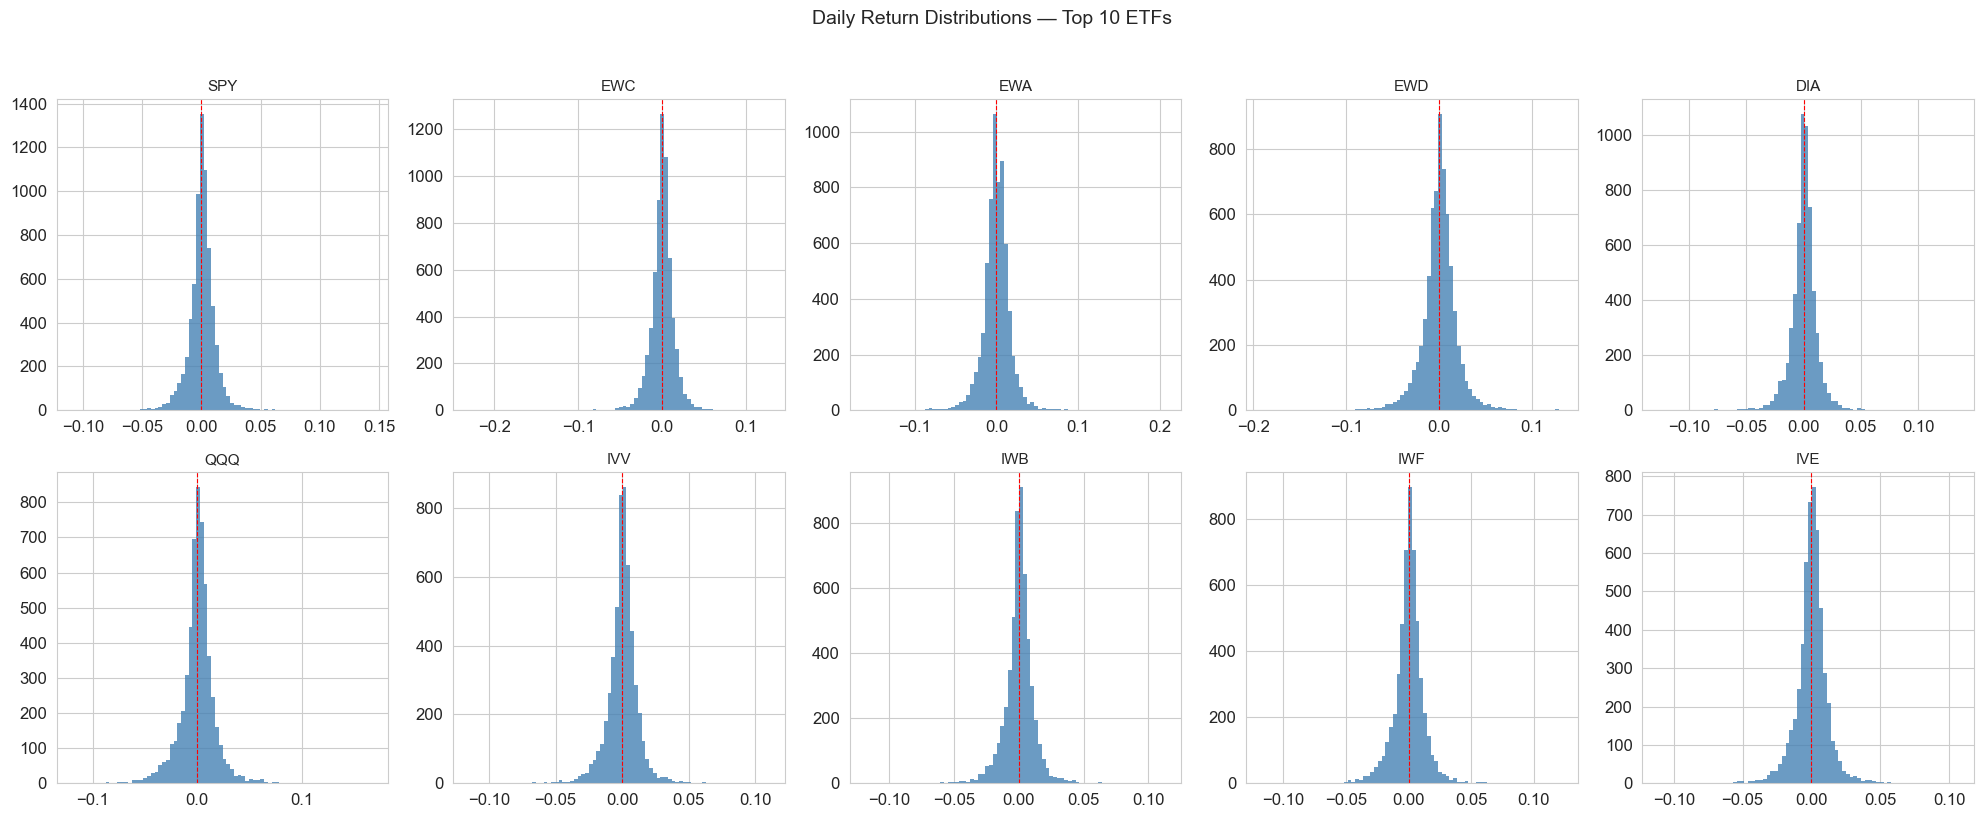

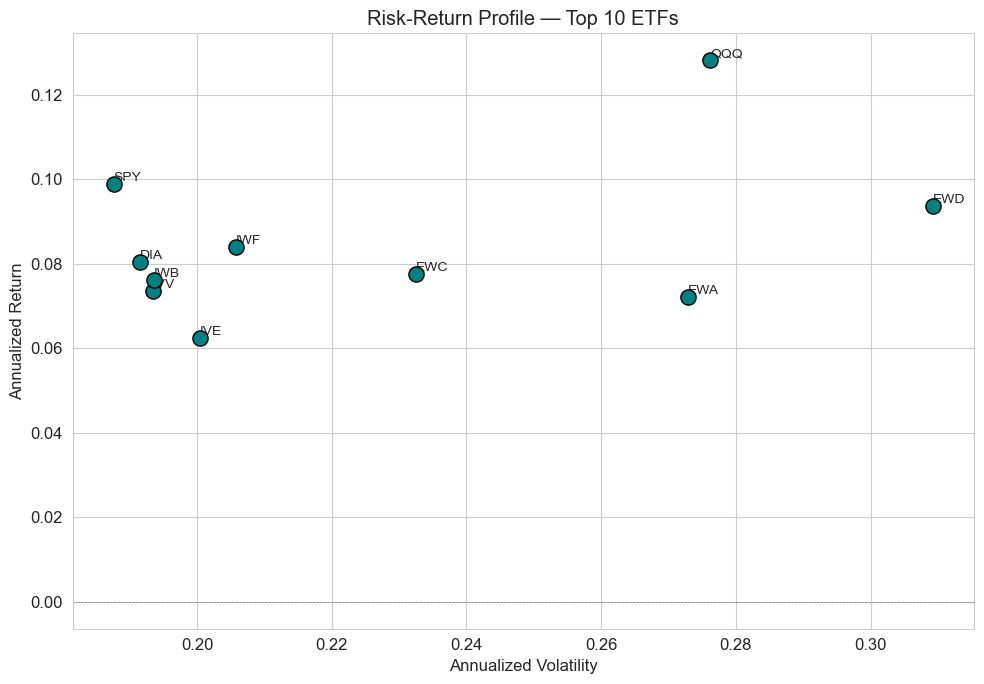

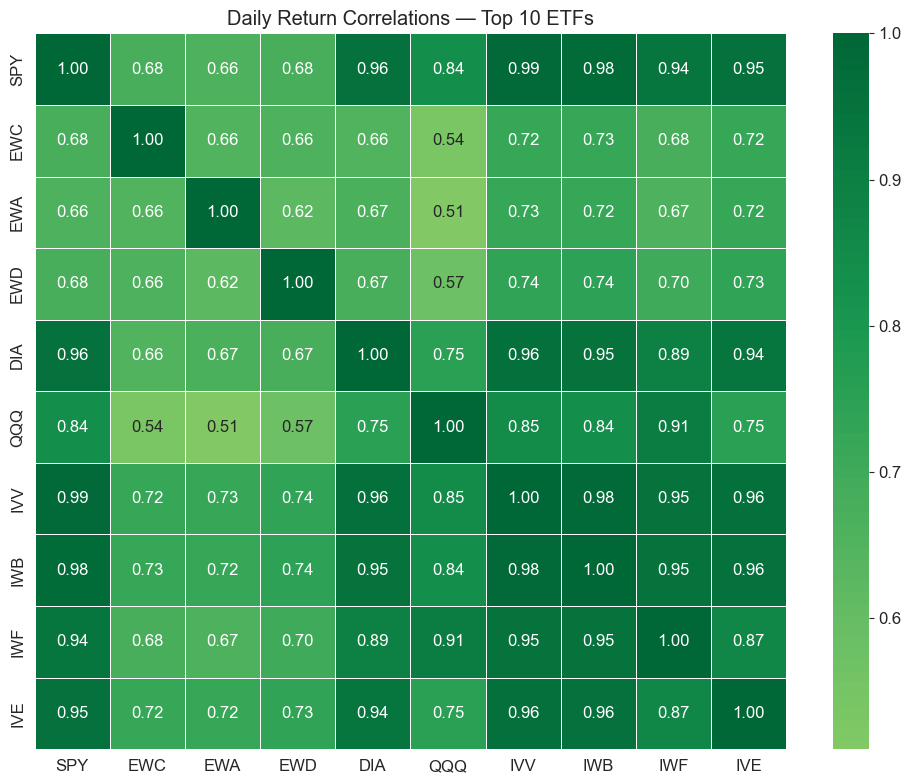

In [42]:
# 11. ETF Returns & Volatility

etf_returns = pd.DataFrame()
for sym in top_etfs:
    sub = etf_prices[etf_prices['fund_symbol'] == sym].sort_values('price_date').set_index('price_date')
    etf_returns[sym] = sub['close'].pct_change()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, sym in enumerate(top_etfs):
    ax = axes[i // 5, i % 5]
    etf_returns[sym].dropna().hist(bins=80, ax=ax, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(sym, fontsize=11)
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.suptitle('Daily Return Distributions — Top 10 ETFs', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

ann_vol = etf_returns.std() * np.sqrt(252)
ann_ret = etf_returns.mean() * 252

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(ann_vol, ann_ret, s=120, c='teal', edgecolors='black', zorder=5)
for t in top_etfs:
    ax.annotate(t, (ann_vol[t], ann_ret[t]), fontsize=10, ha='left', va='bottom')
ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Return')
ax.set_title('Risk-Return Profile — Top 10 ETFs')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(etf_returns.corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Daily Return Correlations — Top 10 ETFs')
plt.tight_layout(); plt.show()


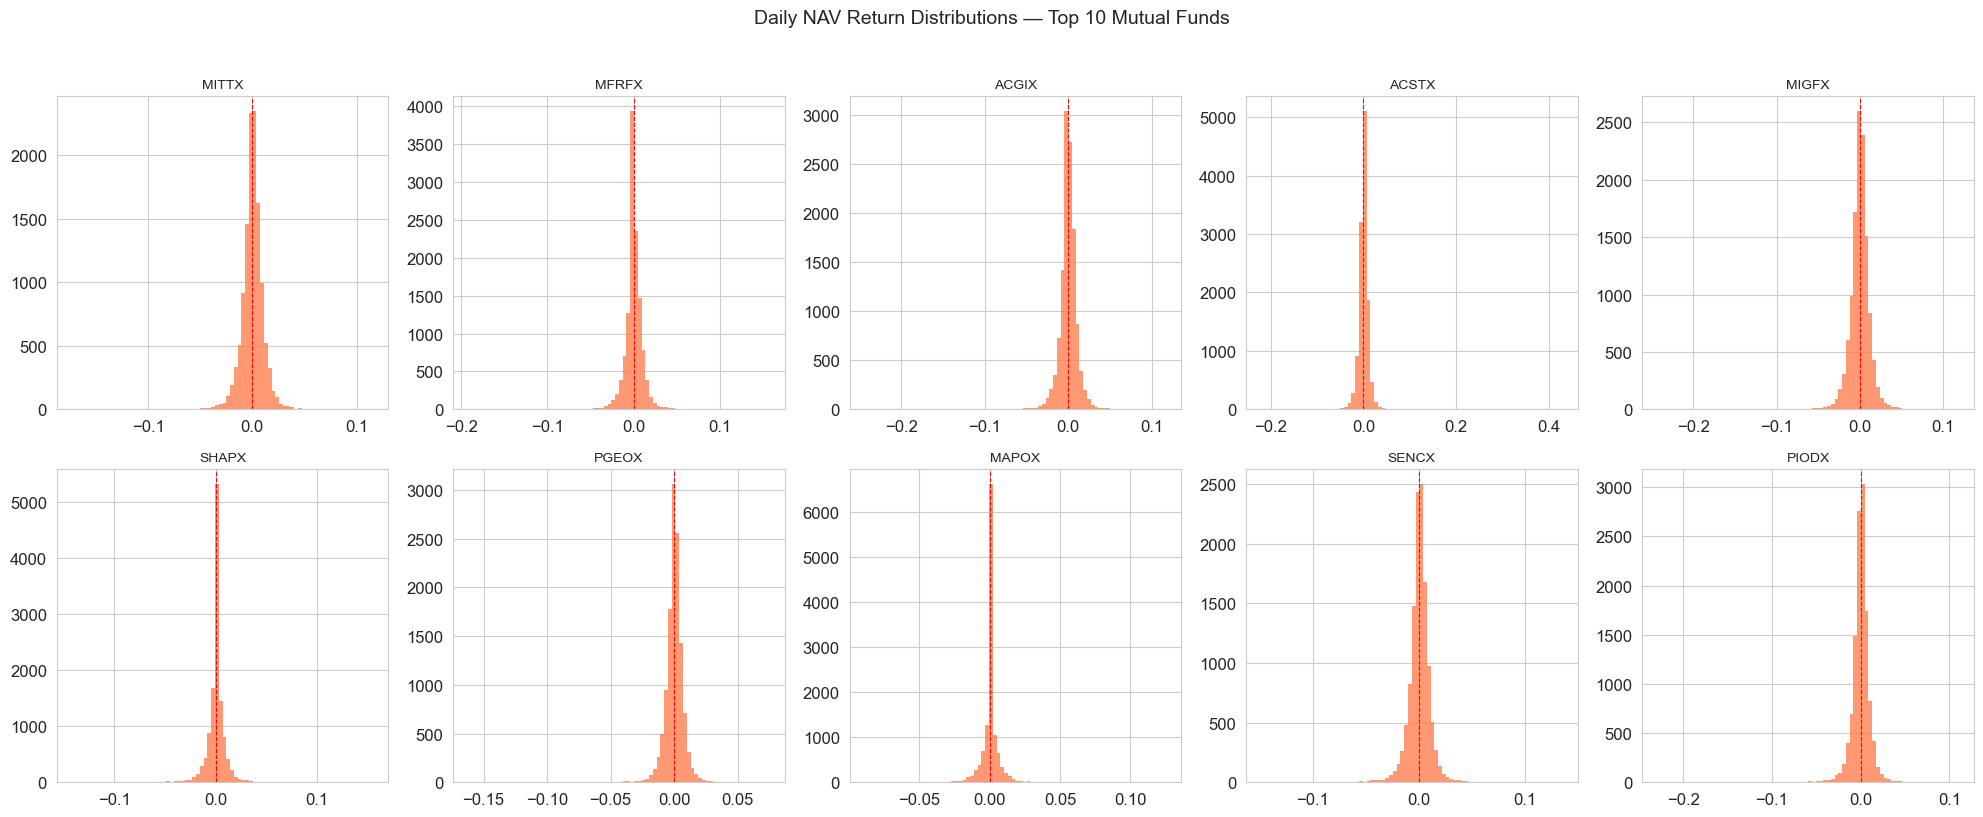

In [44]:
#12. MF NAV Returns & Volatility

mf_returns = pd.DataFrame()
for t in top_mfs:
    sub = mf_prices[mf_prices['ticker'] == t].sort_values('price_date').set_index('price_date')
    mf_returns[t] = sub['nav_per_share'].pct_change()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, t in enumerate(top_mfs):
    ax = axes[i // 5, i % 5]
    mf_returns[t].dropna().hist(bins=80, ax=ax, color='coral', edgecolor='none', alpha=0.8)
    ax.set_title(t, fontsize=10)
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.suptitle('Daily NAV Return Distributions — Top 10 Mutual Funds', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

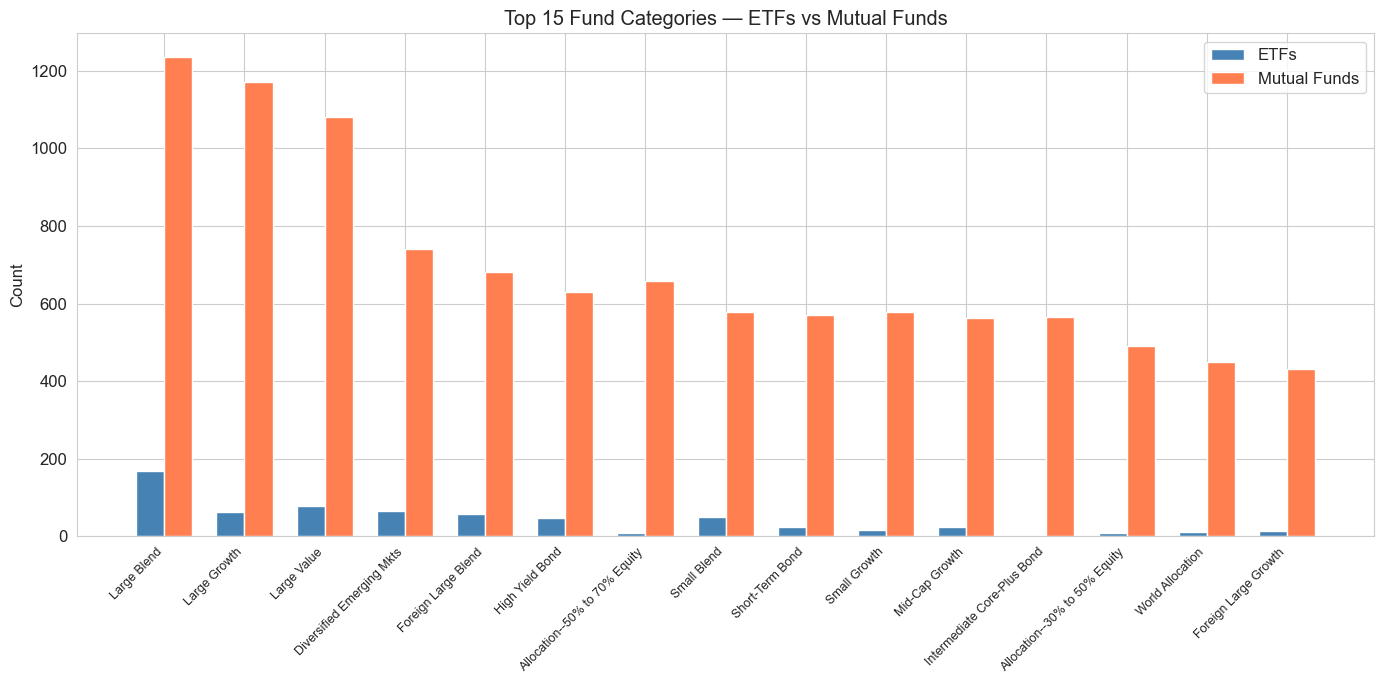

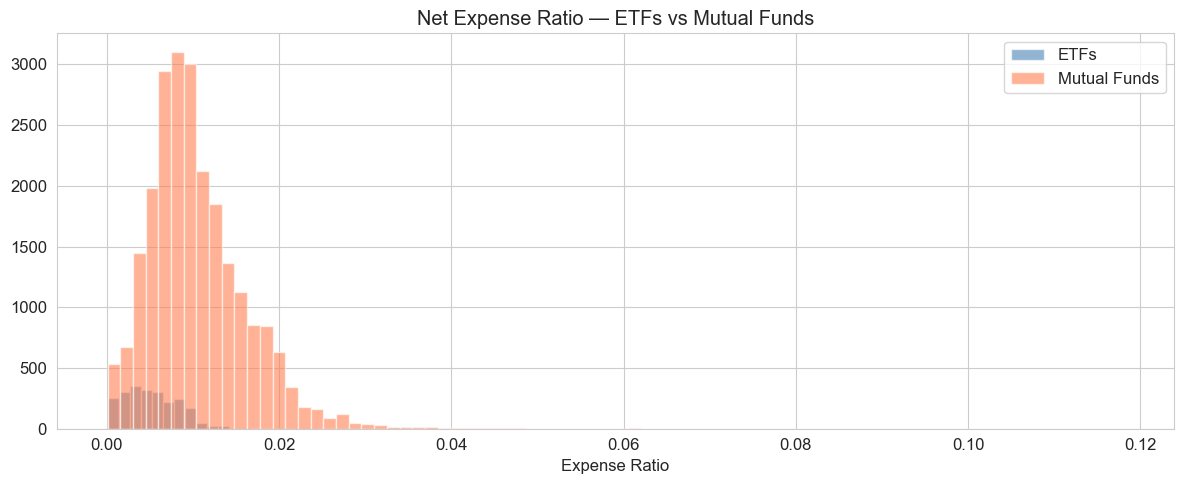

ETF Expense Ratio:
count    2295.000000
mean        0.005553
std         0.004413
min         0.000200
25%         0.002900
50%         0.005000
75%         0.007500
max         0.102300
Name: fund_annual_report_net_expense_ratio, dtype: float64

MF Expense Ratio:
count    23573.000000
mean         0.010473
std          0.005793
min          0.000100
25%          0.006600
50%          0.009500
75%          0.013400
max          0.118000
Name: fund_annual_report_net_expense_ratio, dtype: float64


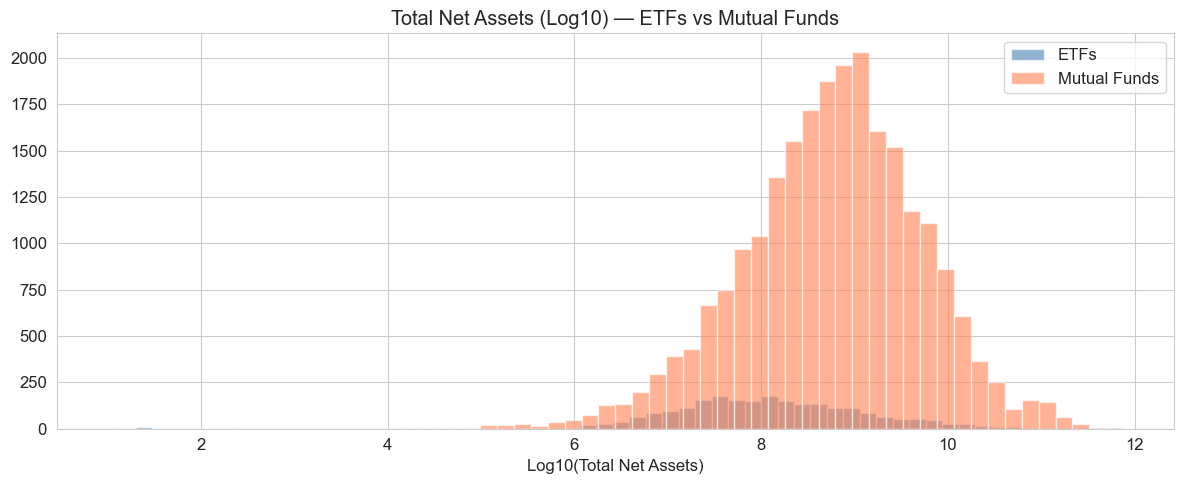

ETF-only families:   0
MF-only families:    160
Both ETF & MF:       150


In [46]:
# 13. ETF vs Mutual Fund Comparison

etf_cat = etf_info['fund_category'].value_counts().rename('ETF')
mf_cat = mf_info['fund_category'].value_counts().rename('MF')
combined = pd.concat([etf_cat, mf_cat], axis=1).fillna(0)
combined['total'] = combined.sum(axis=1)
top15 = combined.sort_values('total', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(top15))
w = 0.35
ax.bar([i - w/2 for i in x], top15['ETF'], w, label='ETFs', color='steelblue')
ax.bar([i + w/2 for i in x], top15['MF'], w, label='Mutual Funds', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(top15.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 15 Fund Categories — ETFs vs Mutual Funds')
ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()

# Expense Ratio comparison
fig, ax = plt.subplots(figsize=(12, 5))
etf_info['fund_annual_report_net_expense_ratio'].dropna().clip(upper=5).hist(
    bins=80, ax=ax, alpha=0.6, label='ETFs', color='steelblue')
mf_info['fund_annual_report_net_expense_ratio'].dropna().clip(upper=5).hist(
    bins=80, ax=ax, alpha=0.6, label='Mutual Funds', color='coral')
ax.set_title('Net Expense Ratio — ETFs vs Mutual Funds')
ax.set_xlabel('Expense Ratio'); ax.legend()
plt.tight_layout(); plt.show()

print("ETF Expense Ratio:")
print(etf_info['fund_annual_report_net_expense_ratio'].describe())
print("\nMF Expense Ratio:")
print(mf_info['fund_annual_report_net_expense_ratio'].describe())

# Total Net Assets comparison (log scale)
fig, ax = plt.subplots(figsize=(12, 5))
for label, df, color in [('ETFs', etf_info, 'steelblue'), ('Mutual Funds', mf_info, 'coral')]:
    vals = df['total_net_assets'].dropna()
    vals = np.log10(vals[vals > 0])
    ax.hist(vals, bins=60, alpha=0.6, label=label, color=color)
ax.set_title('Total Net Assets (Log10) — ETFs vs Mutual Funds')
ax.set_xlabel('Log10(Total Net Assets)'); ax.legend()
plt.tight_layout(); plt.show()

# Fund family overlap
etf_families = set(etf_info['fund_family'].dropna().unique())
mf_families = set(mf_info['fund_family'].dropna().unique())
both = etf_families & mf_families
print(f"ETF-only families:   {len(etf_families - mf_families)}")
print(f"MF-only families:    {len(mf_families - etf_families)}")
print(f"Both ETF & MF:       {len(both)}")

Sector columns (11): ['fund_sector_basic_materials', 'fund_sector_communication_services', 'fund_sector_consumer_cyclical', 'fund_sector_consumer_defensive', 'fund_sector_energy', 'fund_sector_financial_services', 'fund_sector_healthcare', 'fund_sector_industrials', 'fund_sector_real_estate', 'fund_sector_technology', 'fund_sector_utilities']


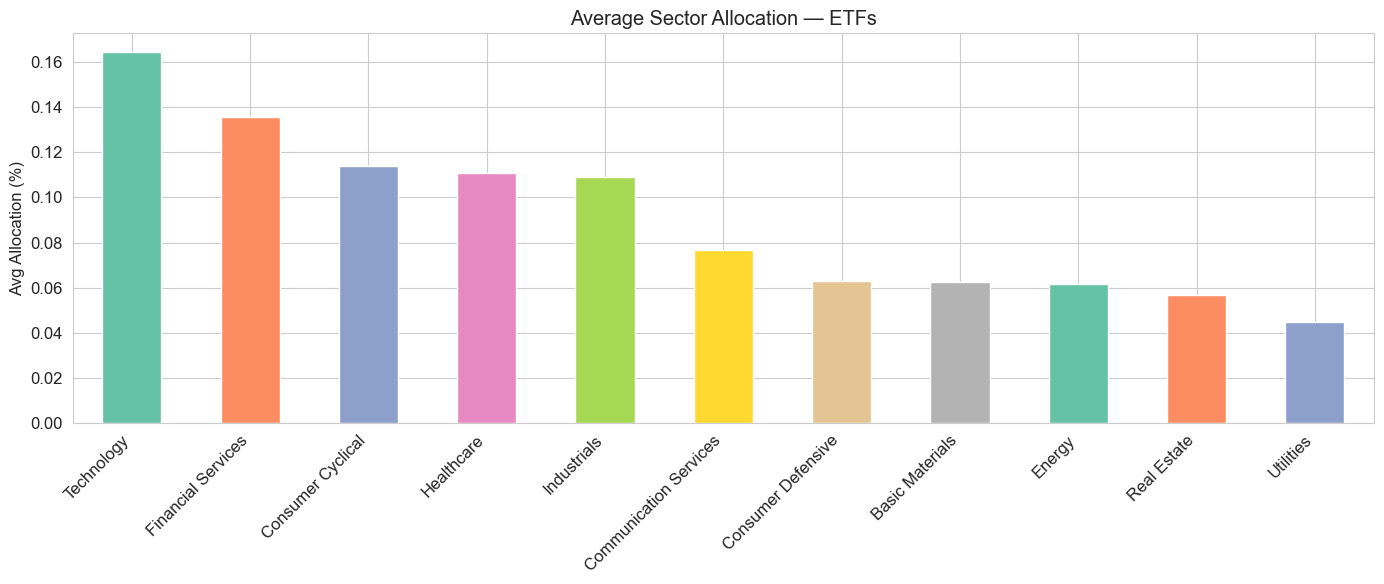

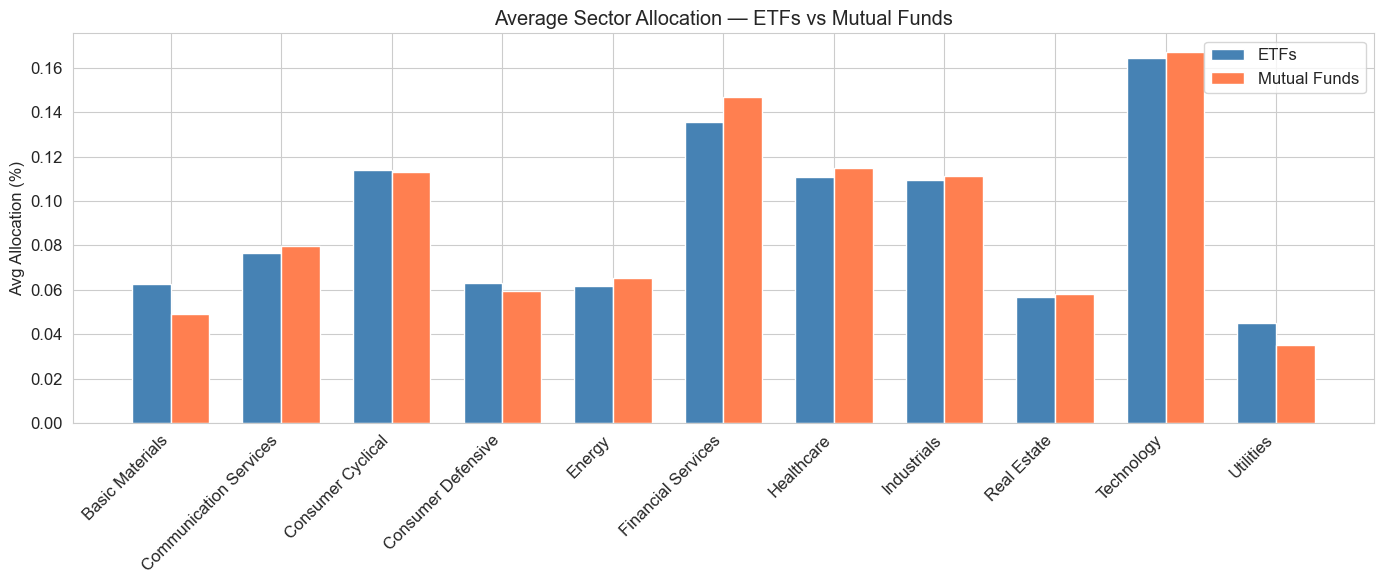

In [48]:
# 14. Sector Allocation Analysis

sector_cols = [c for c in etf_info.columns if c.startswith('fund_sector_')]
print(f"Sector columns ({len(sector_cols)}):", sector_cols)

etf_sector = etf_info[sector_cols].mean().sort_values(ascending=False)
labels = [c.replace('fund_sector_', '').replace('_', ' ').title() for c in etf_sector.index]

fig, ax = plt.subplots(figsize=(14, 6))
etf_sector.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(etf_sector)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Average Sector Allocation — ETFs')
ax.set_ylabel('Avg Allocation (%)')
plt.tight_layout(); plt.show()

mf_sector_cols = [c for c in mf_info.columns if c.startswith('fund_sector_')]
mf_sector = mf_info[mf_sector_cols].mean().sort_values(ascending=False)

# Side-by-side ETF vs MF sectors
common_sectors = sorted(set(sector_cols) & set(mf_sector_cols))
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(common_sectors))
w = 0.35
ax.bar(x - w/2, etf_info[common_sectors].mean(), w, label='ETFs', color='steelblue')
ax.bar(x + w/2, mf_info[common_sectors].mean(), w, label='Mutual Funds', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('fund_sector_', '').replace('_', ' ').title() for c in common_sectors],
                   rotation=45, ha='right')
ax.set_title('Average Sector Allocation — ETFs vs Mutual Funds')
ax.set_ylabel('Avg Allocation (%)'); ax.legend()
plt.tight_layout(); plt.show()

Available: ['SPY', 'QQQ', 'IWM', 'EFA', 'GLD', 'BND']


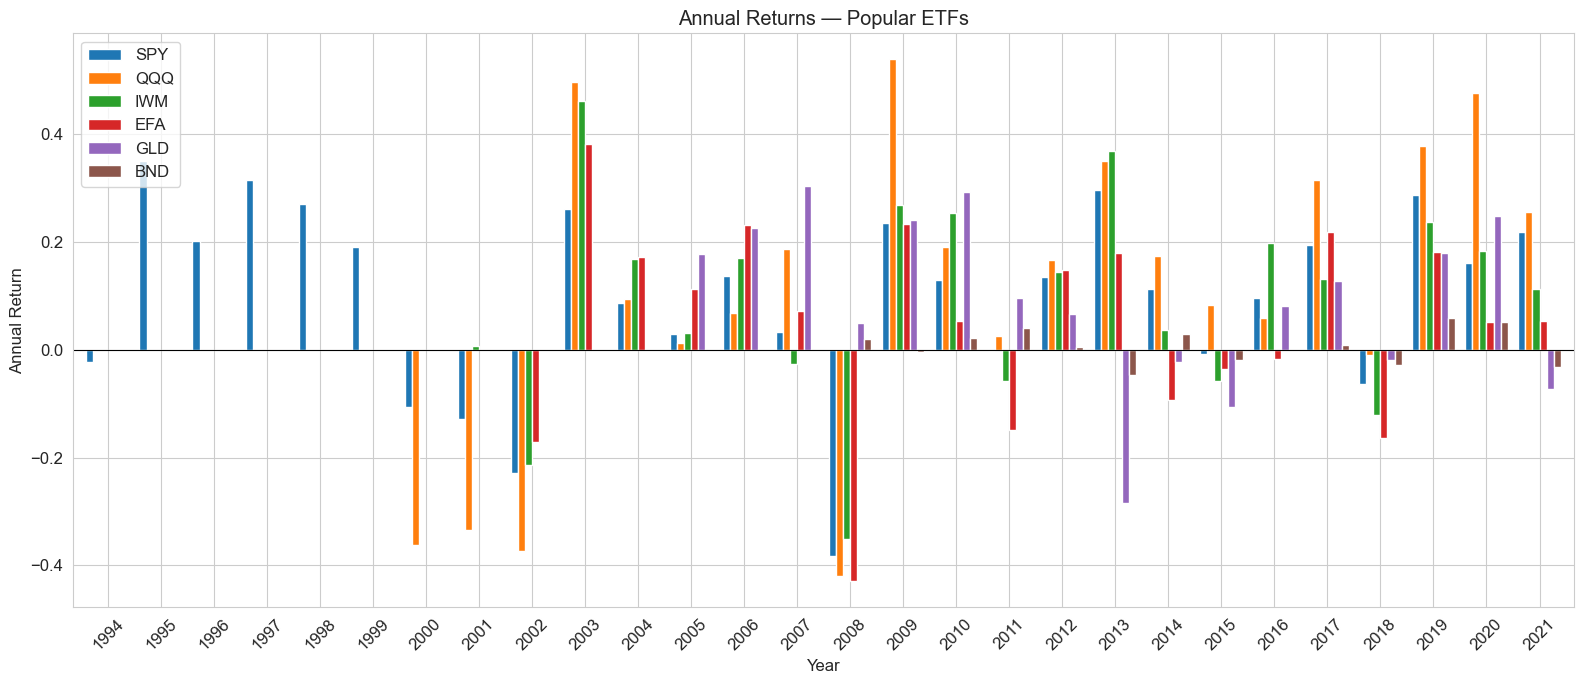

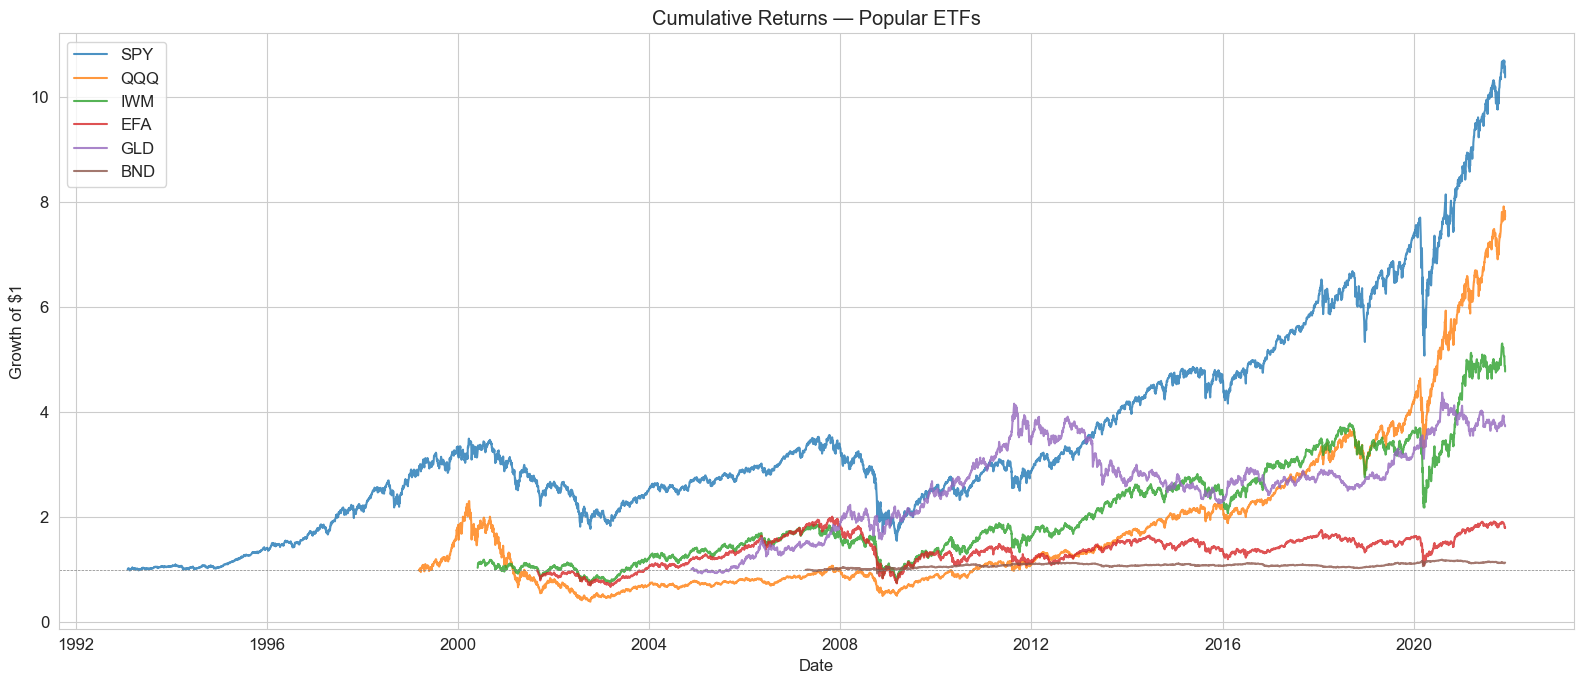

In [50]:
# 15. Year-over-Year Performance — Popular ETFs

well_known = ['SPY', 'QQQ', 'IWM', 'EFA', 'AGG', 'GLD', 'VTI', 'BND']
available = [s for s in well_known if s in etf_prices['fund_symbol'].unique()]
print(f"Available: {available}")

annual_returns = {}
for sym in available:
    sub = etf_prices[etf_prices['fund_symbol'] == sym].sort_values('price_date').set_index('price_date')
    yearly = sub['close'].resample('YE').last().pct_change().dropna()
    yearly.index = yearly.index.year
    annual_returns[sym] = yearly

annual_df = pd.DataFrame(annual_returns)
fig, ax = plt.subplots(figsize=(16, 7))
annual_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Annual Returns — Popular ETFs')
ax.set_xlabel('Year'); ax.set_ylabel('Annual Return')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(loc='upper left'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

# Cumulative returns
fig, ax = plt.subplots(figsize=(16, 7))
for sym in available:
    sub = etf_prices[etf_prices['fund_symbol'] == sym].sort_values('price_date').set_index('price_date')
    cum = (1 + sub['close'].pct_change()).cumprod()
    ax.plot(cum.index, cum.values, label=sym, alpha=0.8)
ax.set_title('Cumulative Returns — Popular ETFs')
ax.set_xlabel('Date'); ax.set_ylabel('Growth of $1')
ax.legend(); ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout(); plt.show()

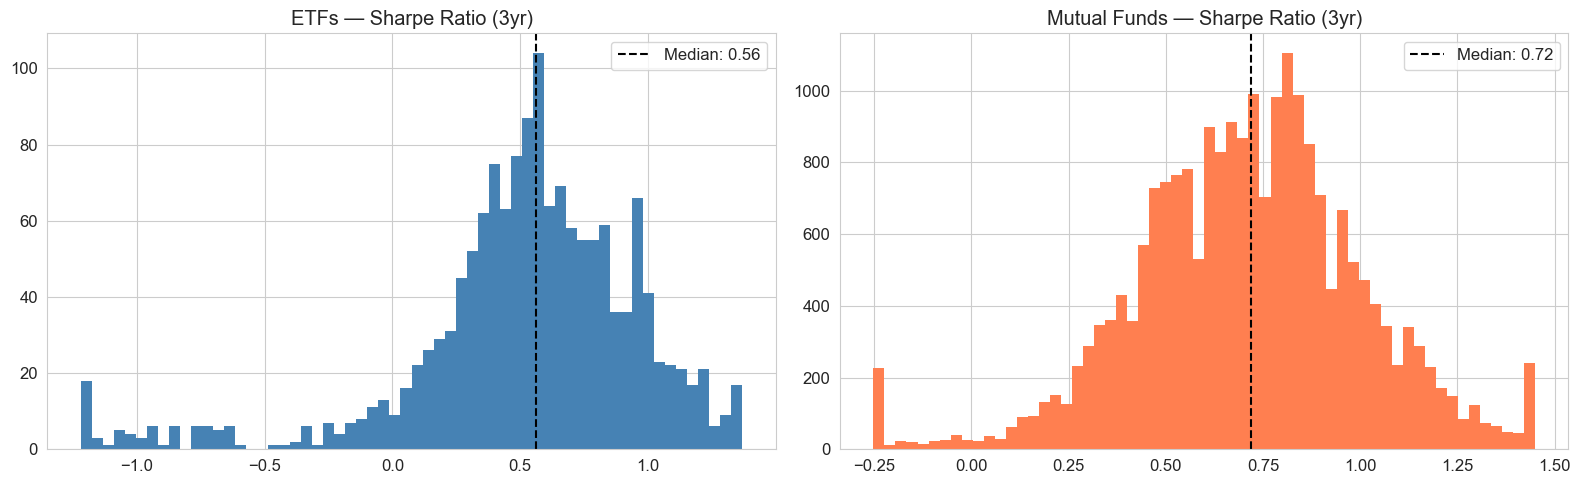

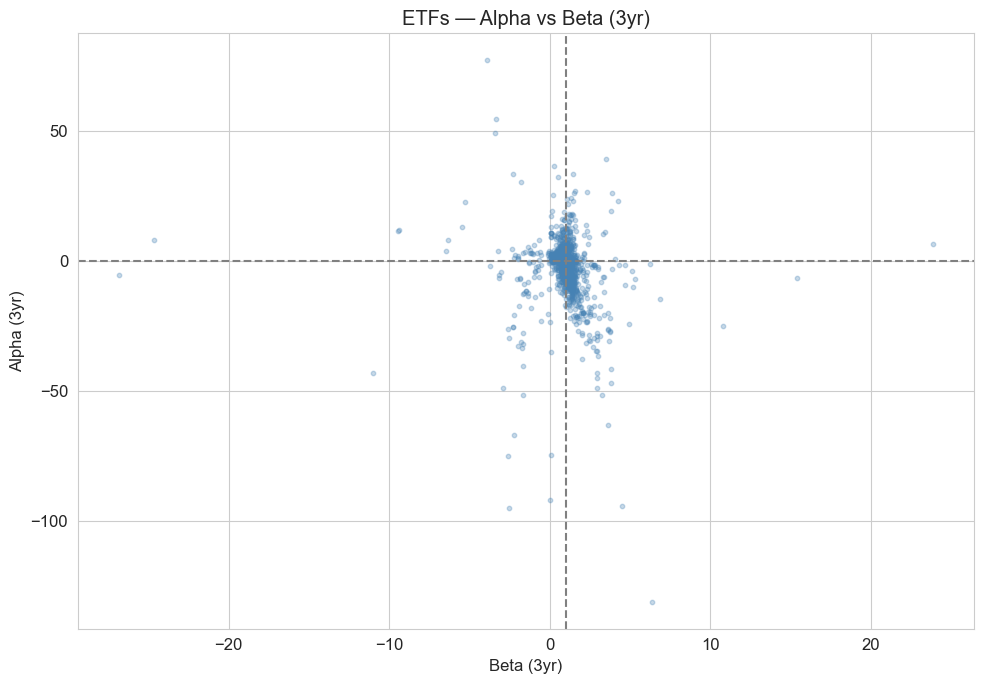

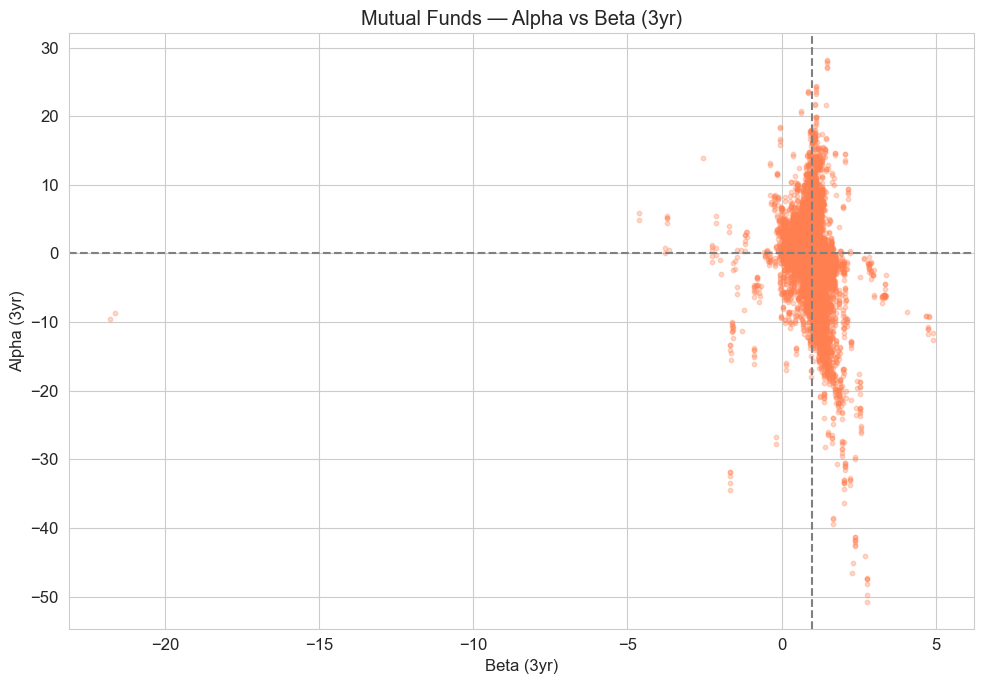

In [52]:
# 16. Risk Metrics from Fund Info

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, (label, df, color) in enumerate([('ETFs', etf_info, 'steelblue'), ('Mutual Funds', mf_info, 'coral')]):
    col = 'fund_sharpe_ratio_3years'
    if col in df.columns:
        data = df[col].dropna()
        data.clip(lower=data.quantile(0.01), upper=data.quantile(0.99)).hist(
            bins=60, ax=axes[i], color=color, edgecolor='none')
        axes[i].set_title(f'{label} — Sharpe Ratio (3yr)')
        axes[i].axvline(data.median(), color='black', linestyle='--', label=f'Median: {data.median():.2f}')
        axes[i].legend()
plt.tight_layout(); plt.show()

for label, df, color in [('ETFs', etf_info, 'steelblue'), ('Mutual Funds', mf_info, 'coral')]:
    a_col, b_col = 'fund_alpha_3years', 'fund_beta_3years'
    if a_col in df.columns and b_col in df.columns:
        sub = df[[a_col, b_col]].dropna()
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.scatter(sub[b_col], sub[a_col], alpha=0.3, s=10, c=color)
        ax.set_xlabel('Beta (3yr)'); ax.set_ylabel('Alpha (3yr)')
        ax.set_title(f'{label} — Alpha vs Beta (3yr)')
        ax.axhline(0, color='gray', linestyle='--'); ax.axvline(1, color='gray', linestyle='--')
        plt.tight_layout(); plt.show()

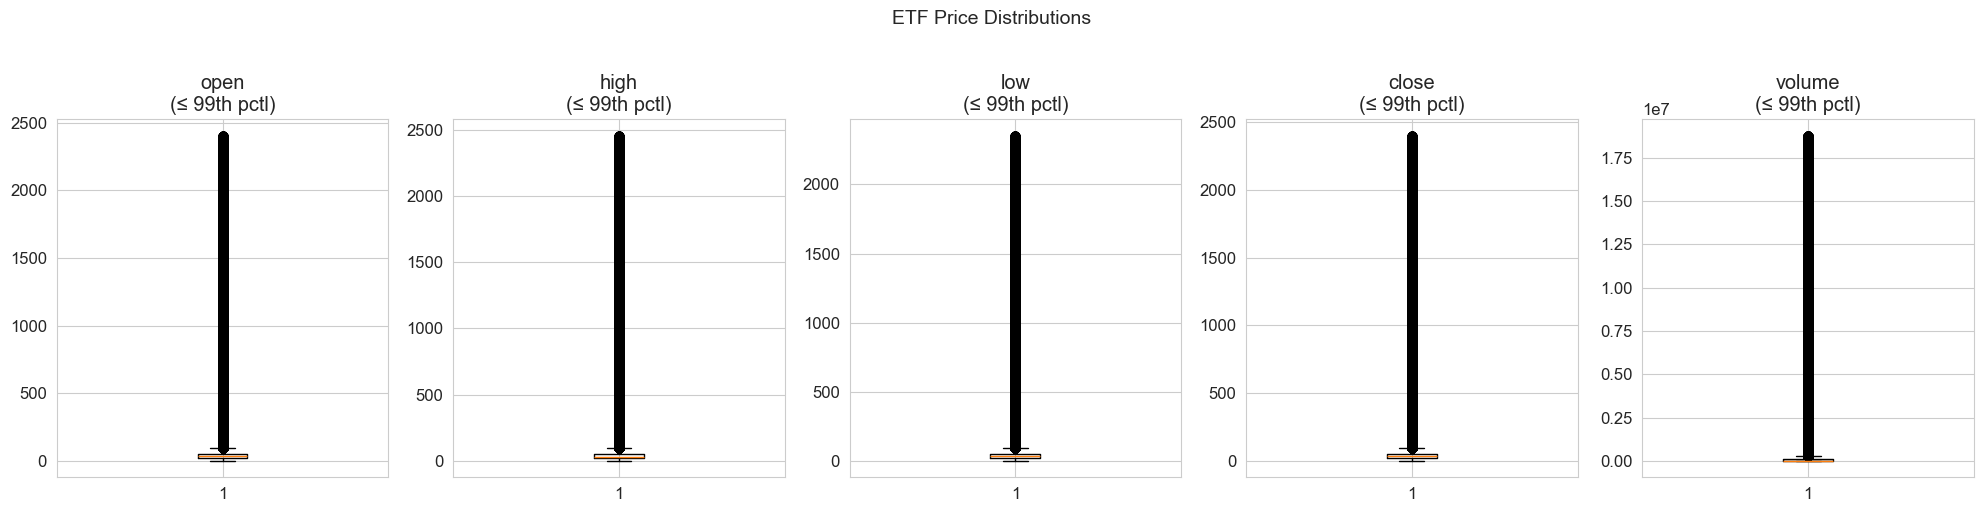

Duplicate rows:
  ETF Prices:  0
  ETF Info:    0
  MF Prices:   0
  MF Info:     0

Duplicate (symbol/ticker, date) pairs:
  ETF Prices:  0
  MF Prices:   0

ETF close ≤ 0: 8
ETF close null: 0
MF nav ≤ 0: 2
MF nav null: 0


In [54]:
# 17. Outlier & Data Quality Checks

price_cols = ['open', 'high', 'low', 'close', 'volume']
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(price_cols):
    data = etf_prices[col].dropna()
    q99 = data.quantile(0.99)
    axes[i].boxplot(data[data <= q99], vert=True)
    axes[i].set_title(f'{col}\n(≤ 99th pctl)')
plt.suptitle('ETF Price Distributions', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("Duplicate rows:")
print(f"  ETF Prices:  {etf_prices.duplicated().sum():,}")
print(f"  ETF Info:    {etf_info.duplicated().sum():,}")
print(f"  MF Prices:   {mf_prices.duplicated().sum():,}")
print(f"  MF Info:     {mf_info.duplicated().sum():,}")

print(f"\nDuplicate (symbol/ticker, date) pairs:")
print(f"  ETF Prices:  {etf_prices.duplicated(subset=['fund_symbol', 'price_date']).sum():,}")
print(f"  MF Prices:   {mf_prices.duplicated(subset=['ticker', 'price_date']).sum():,}")

print("\nETF close ≤ 0:", (etf_prices['close'] <= 0).sum())
print("ETF close null:", etf_prices['close'].isnull().sum())
print("MF nav ≤ 0:", (mf_prices['nav_per_share'] <= 0).sum())
print("MF nav null:", mf_prices['nav_per_share'].isnull().sum())

In [55]:
# 18. Summary

print("=" * 60)
print("📊 DATASET SUMMARY")
print("=" * 60)
print(f"\nETFs tracked:              {etf_info['fund_symbol'].nunique():,}")
print(f"ETF price records:         {etf_prices.shape[0]:,}")
print(f"Mutual Funds tracked:      {mf_info['fund_symbol'].nunique():,}")
print(f"MF price records:          {mf_prices.shape[0]:,}")
print(f"  (from 4 split files: A-E, F-K, L-P, Q-Z)")
print(f"\nETF price date range:      {etf_prices['price_date'].min().date()} → {etf_prices['price_date'].max().date()}")
print(f"MF price date range:       {mf_prices['price_date'].min().date()} → {mf_prices['price_date'].max().date()}")
print(f"\nUnique ETF categories:     {etf_info['fund_category'].nunique()}")
print(f"Unique MF categories:      {mf_info['fund_category'].nunique()}")
print(f"Unique ETF fund families:  {etf_info['fund_family'].nunique()}")
print(f"Unique MF fund families:   {mf_info['fund_family'].nunique()}")
print(f"\nETF Info columns:          {etf_info.shape[1]}")
print(f"MF Info columns:           {mf_info.shape[1]}")
print(f"\nKey differences:")
print(f"  ETF prices: fund_symbol + OHLCV (open/high/low/close/adj_close/volume)")
print(f"  MF prices:  ticker + nav_per_share only")
print(f"  MF info has: Morningstar ratings, ESG scores, quarterly returns, sales loads")

📊 DATASET SUMMARY

ETFs tracked:              2,310
ETF price records:         3,866,030
Mutual Funds tracked:      23,783
MF price records:          75,657,739
  (from 4 split files: A-E, F-K, L-P, Q-Z)

ETF price date range:      1993-01-29 → 2021-11-30
MF price date range:       1973-05-03 → 2021-11-30

Unique ETF categories:     83
Unique MF categories:      119
Unique ETF fund families:  150
Unique MF fund families:   310

ETF Info columns:          142
MF Info columns:           298

Key differences:
  ETF prices: fund_symbol + OHLCV (open/high/low/close/adj_close/volume)
  MF prices:  ticker + nav_per_share only
  MF info has: Morningstar ratings, ESG scores, quarterly returns, sales loads
